## Figures for the thesis

#### Functions

In [1]:
# shared helpers
import json, re, subprocess
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

BASE  = Path("..")                                   # repo root, from notebooks/
ROOT  = BASE / "dataset/deliverable_dataset"         # <site>/full_plate/{train_stitched,grid_1024}
SITES = ["Belgium", "Crete"]

coco    = {s: json.load(open(ROOT / s / "full_plate/annotations.coco.json")) for s in SITES}
grid    = {s: json.load(open(ROOT / s / "full_plate/grid_1024/annotations.coco.json")) for s in SITES}
catname = {c["id"]: c["name"] for c in coco["Belgium"]["categories"]}   # the 57 are shared
name2id = {v: k for k, v in catname.items()}

# the 5 target classes per site (their union is the 8-class label space); drives the red/grey
# bars, the gallery columns and the plate legend
TARGET5 = {
    "Belgium": ["Serpulidae", "Spirobranchus", "Membraniporoidea", "Crepidula fornicata", "Hydrozoa"],
    "Crete":   ["Spirorbinae", "Serpulidae", "Rhodophyta", "Spirobranchus", "Ciona"],
}
RED, GRAY = "#d62728", "#6A6A6A"
CLS_COL = dict(zip(sorted(set(TARGET5["Belgium"]) | set(TARGET5["Crete"])),
                   ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                    "#9467bd", "#d62728", "#17becf", "#8c564b"]))
plt.rcParams["svg.fonttype"] = "none"                # labels stay real text inside the SVG


def save_pdf_tex(fig, name, out=BASE / "notebooks/visuals_out"):
    """SVG -> PDF + .pdf_tex, the Inkscape export the other figures in Images/ use.
    svg.fonttype='none' keeps text as text, which is what lets Inkscape lift the labels
    out into the .pdf_tex overlay for LaTeX to typeset. Call BEFORE plt.show(): the
    inline backend closes the figure on show, and you would export a blank canvas."""
    inkscape = Path.home() / ".conda/envs/torch-arms/bin/inkscape"
    out.mkdir(parents=True, exist_ok=True)
    svg = out / f"{name}.svg"
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig.savefig(svg)                             # no bbox_inches="tight": keep the exact width
    r = subprocess.run([str(inkscape), "-D", "--export-type=pdf", "--export-latex",
                        f"--export-filename={out / (name + '.pdf')}", str(svg)],
                       capture_output=True, text=True)
    print(f"wrote {name}.pdf + {name}.pdf_tex" if r.returncode == 0
          else f"inkscape failed: {r.stderr.strip()[:200]}")


def dist(site):
    """Instance count per class at `site`, descending."""
    return pd.Series(Counter(catname[a["category_id"]] for a in coco[site]["annotations"])
                     ).sort_values(ascending=False)


def nobox(ax):
    """Strip the frame and ticks off an image axes."""
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)


# ---- example crops -------------------------------------------------------------------------
_PLATE = {}                                          # plates are ~5000 px, do not reopen per crop


def plate_img(site, stem):
    if (site, stem) not in _PLATE:
        _PLATE[(site, stem)] = Image.open(
            ROOT / site / "full_plate/train_stitched" / f"{stem}.jpg").convert("RGB")
    return _PLATE[(site, stem)]


def _fit(img, mode, bg=(255, 255, 255)):
    """'pad' -> letterbox to a square with white (keeps all context; adds white margins).
    'crop' -> center-crop to a square (fills the cell edge to edge; trims extra background)."""
    w, h = img.size
    if mode == "pad":
        s = max(w, h); c = Image.new("RGB", (s, s), bg); c.paste(img, ((s - w) // 2, (s - h) // 2)); return c
    s = min(w, h); l, t = (w - s) // 2, (h - s) // 2
    return img.crop((l, t, l + s, t + s))


def crop_inst(site, ann, imgs, fit, alpha=0.17, pad_frac=0.10):
    """One instance cut from its plate with the mask tinted red."""
    im = imgs[ann["image_id"]]; stem = Path(im["file_name"]).stem
    x, y, w, h = [int(v) for v in ann["bbox"]]
    pad = int(pad_frac * max(w, h))
    x0, y0 = max(0, x - pad), max(0, y - pad); x1, y1 = x + w + pad, y + h + pad
    base = plate_img(site, stem).crop((x0, y0, x1, y1))
    mask = Image.new("L", base.size, 0); md = ImageDraw.Draw(mask)
    for seg in ann["segmentation"]:
        pts = [(px - x0, py - y0) for px, py in zip(seg[0::2], seg[1::2])]
        if len(pts) >= 3:
            md.polygon(pts, fill=255)
    overlay = Image.new("RGB", base.size, (255, 0, 0))
    return _fit(Image.composite(Image.blend(base, overlay, alpha), base, mask), fit)


def pick_insts(site, cname, anns, per, picks, exclude):
    """PICKS first, in the given order, then the largest instances that are not excluded.
    Ids listed for the wrong class or site are reported and ignored, so a bad paste cannot
    pass silently and leave a figure showing something other than what it claims."""
    by_id = {a["id"]: a for a in anns}
    out, seen = [], set()
    for aid in picks.get((site, cname), []):
        if aid in by_id:
            out.append(by_id[aid]); seen.add(aid)
        else:
            print(f"  ! {site}/{cname}: ann {aid} is not an annotation of this class, ignored")
    if len(out) > per:
        print(f"  ! {site}/{cname}: {len(out)} picks for {per} slots, showing the first {per}")
    fill = [a for a in sorted(anns, key=lambda a: -a["area"])
            if a["id"] not in seen and a["id"] not in exclude.get(site, set())]
    return (out + fill)[:per]


def gallery(site, classes, per, layout, picks, exclude, cell=None, figsize=None,
            space=None, fit="pad", show_ids=True, id_fs=6, lbl_fs=9):
    """Grid of example crops. layout='cols' -> classes are COLUMNS (wide); 'rows' -> classes
    are ROWS (tall page). `figsize` fixes the figure size (for a one-page FULL); else `cell`
    sizes each thumbnail. `space` sets the inter-crop gap; `fit` is 'pad' or 'crop'.
    Returns the figure, so the calling cell owns the saving."""
    imgs = {i["id"]: i for i in coco[site]["images"]}
    by_cat = {}
    for a in coco[site]["annotations"]:
        by_cat.setdefault(a["category_id"], []).append(a)
    nrow, ncol = (per, len(classes)) if layout == "cols" else (len(classes), per)
    pos = (lambda ci, ei: (ei, ci)) if layout == "cols" else (lambda ci, ei: (ci, ei))
    fig, ax = plt.subplots(nrow, ncol, figsize=figsize or (ncol * cell, nrow * cell), squeeze=False)
    for a_ in ax.ravel():
        nobox(a_)
    for ci, cname in enumerate(classes):
        anns = pick_insts(site, cname, by_cat.get(name2id[cname], []), per, picks, exclude)
        for ei in range(per):
            r, c = pos(ci, ei)
            if ei < len(anns):
                ax[r, c].imshow(crop_inst(site, anns[ei], imgs, fit))
                if show_ids:
                    ax[r, c].set_xlabel(str(anns[ei]["id"]), fontsize=id_fs, labelpad=1.5)
        lbl = f"{cname}\n(n={len(by_cat.get(name2id[cname], []))})"   # class label, not a title
        if layout == "cols":
            ax[0, ci].set_title(lbl, fontsize=lbl_fs)
        else:
            ax[ci, 0].set_ylabel(lbl, rotation=0, ha="right", va="center", fontsize=lbl_fs - 1)
    if space is not None:                            # tight, page-fitted layout (FULL)
        left = 0.22 if layout == "rows" else 0.02    # room for the row labels on the left
        fig.subplots_adjust(left=left, right=0.995, top=0.955, bottom=0.02,
                            wspace=space, hspace=max(space, 0.35))   # hspace: room for the ann id
    else:
        fig.tight_layout()
    return fig


def topN(site, n):
    return [catname[cid] for cid, _ in Counter(
        a["category_id"] for a in coco[site]["annotations"]).most_common(n)]


# ---- whole plate: how it is tiled, and what is annotated on it -------------------------------
# Tiling as in build_plate_grid.py: xs = list(range(0, W - t, t)) + [W - t] (same for y), so
# the last column and row are moved in to the plate edge and overlap their neighbour:
#   Belgium 4864x3328 -> 256 px horizontal overlap, 768 px vertical
#   Crete   5629x3787 -> 515 px horizontal, 309 px vertical
# No instance is duplicated: each annotation belongs to the one tile holding its bbox centre
# (Belgium 5362 tile annotations for 5362 plate ids, Crete 11276 for 11276). The figure shades
# the overlapping bands.
def tile_origins(site, stem):
    """Top-left corner of every 1024 tile cut from this plate, read back from the grid
    filenames rather than recomputed, so the figure cannot drift from the actual tiling."""
    out = []
    for im in grid[site]["images"]:
        m = re.match(rf"^{re.escape(stem)}_x(\d+)_y(\d+)\.jpg$", im["file_name"])
        if m:
            out.append((int(m.group(1)), int(m.group(2))))
    return sorted(out)


def overlap_spans(vals, tile):
    """Intervals along one axis covered by two tiles, i.e. where the snapped edge tile
    doubles back over its neighbour."""
    v = sorted(set(vals))
    return [(v[i + 1], v[i] + tile) for i in range(len(v) - 1) if v[i + 1] - v[i] < tile]


def busiest_plate(site):
    """Stem of the plate carrying the most annotations, so the overlay panel is not sparse."""
    stem_of = {i["id"]: Path(i["file_name"]).stem for i in coco[site]["images"]}
    return Counter(stem_of[a["image_id"]] for a in coco[site]["annotations"]).most_common(1)[0][0]


def plate_scaled(site, stem, max_px):
    """Plate downscaled for display, with the scale factor so overlays stay registered."""
    img = Image.open(ROOT / site / "full_plate/train_stitched" / f"{stem}.jpg").convert("RGB")
    W, H = img.size
    k = min(1.0, max_px / max(W, H))
    return img.resize((int(W * k), int(H * k)), Image.LANCZOS), k, W, H


def plate_anns(site, stem):
    iid = next(i["id"] for i in coco[site]["images"] if Path(i["file_name"]).stem == stem)
    return [a for a in coco[site]["annotations"] if a["image_id"] == iid]


def draw_tiles(ax, origins, k, tile=1024, lw=0.6, col="#ffd400", shade="#ff3b30", show_overlap=True):
    """Tile outlines, plus the doubled bands tinted so the snapped edge reads as deliberate."""
    for ox, oy in origins:
        ax.add_patch(plt.Rectangle((ox * k, oy * k), tile * k, tile * k,
                                   fill=False, ec=col, lw=lw, alpha=0.9))
    if show_overlap:
        # limited to the tiled area, so the background around the plate isn't tinted
        xs = [o[0] for o in origins]; ys = [o[1] for o in origins]
        x_lo, x_hi = min(xs) * k, (max(xs) + tile) * k
        y_lo, y_hi = min(ys) * k, (max(ys) + tile) * k
        for x0, x1 in overlap_spans(xs, tile):
            ax.add_patch(plt.Rectangle((x0 * k, y_lo), (x1 - x0) * k, y_hi - y_lo,
                                       fc=shade, ec="none", alpha=0.18))
        for y0, y1 in overlap_spans(ys, tile):
            ax.add_patch(plt.Rectangle((x_lo, y0 * k), x_hi - x_lo, (y1 - y0) * k,
                                       fc=shade, ec="none", alpha=0.18))


def draw_anns(ax, site, anns, k, lw=0.3):
    """Annotation polygons, one colour per benchmark class and grey for everything else.
    Returns the per-class counts so the cell can build its own legend."""
    present = Counter()
    for a in anns:
        cname = catname[a["category_id"]]
        col = CLS_COL.get(cname)
        present[cname] += 1
        for seg in a["segmentation"]:
            pts = np.array(seg, float).reshape(-1, 2) * k
            if len(pts) >= 3:
                ax.add_patch(plt.Polygon(pts, closed=True, fc=col or GRAY, ec=col or GRAY,
                                         lw=lw, alpha=0.55 if col else 0.30))
    return present


def class_handles(present):
    h = [plt.Line2D([], [], marker="s", ls="", ms=5, mfc=CLS_COL[c], mec="none",
                    label=f"{c} ({present[c]})") for c in CLS_COL if c in present]
    n_other = sum(v for c, v in present.items() if c not in CLS_COL)
    if n_other:
        h.append(plt.Line2D([], [], marker="s", ls="", ms=5, mfc=GRAY, mec="none",
                            label=f"other classes ({n_other})"))
    return h


# ---- prompts ---------------------------------------------------------------------------------
import sys as _sys                                   # noqa: E402
if str((BASE / "arms_benchmark").resolve()) not in _sys.path:
    _sys.path.insert(0, str((BASE / "arms_benchmark").resolve()))
from arms.prompts import build_prompt, CLICK, SKELY, RANDOM, BBOX, CLICKNEG   # noqa: E402

# Real instances, one per body plan: encrusting sheets (Membraniporoidea, Crepidula) and tube
# worms (Serpulidae, Spirobranchus). Skeleton and Random place points very differently on
# elongated objects, which is why both are in the benchmark.
POS, NEG, OBJ, NBR, BOX_C = "#1baf7a", "#d62728", "#2a78d6", "#d9d9d2", "#eb6834"
TIGHT = "#ffd400"        # visible on both dark Belgium and bright Crete backgrounds


def _poly_mask(seg, H, W):
    im = Image.new("L", (W, H), 0); d = ImageDraw.Draw(im)
    for p in seg:
        if len(p) >= 6:
            d.polygon(list(zip(p[0::2], p[1::2])), fill=1)
    return np.array(im, bool)


def load_example(site, ann_id, pad_frac=0.35):
    """One real instance in TILE space, together with every other instance on its tile.

    Prompts are built on the TILE mask, not on the crop. CLICKNEG looks for a neighbouring
    organism to put its negative on, so cropping first would hide the neighbours and silently
    change the prompt into its hull fallback. The window below is for display only; prompt
    coordinates are shifted into it afterwards."""
    gg = grid[site]
    ann = next(a for a in gg["annotations"] if a["id"] == ann_id)
    im = next(i for i in gg["images"] if i["id"] == ann["image_id"])
    H, W = im["height"], im["width"]
    rgb = np.array(Image.open(ROOT / site / "full_plate/grid_1024/images" / im["file_name"]
                              ).convert("RGB"))
    m = _poly_mask(ann["segmentation"], H, W)
    nbrs = [_poly_mask(a["segmentation"], H, W) for a in gg["annotations"]
            if a["image_id"] == ann["image_id"] and a["id"] != ann_id]
    x, y, w, h = ann["bbox"]
    pad = pad_frac * max(w, h)
    win = (int(max(0, x - pad)), int(max(0, y - pad)),
           int(min(W, x + w + pad)), int(min(H, y + h + pad)))
    return {"rgb": rgb, "mask": m, "nbrs": nbrs, "win": win,
            "cls": catname[ann["category_id"]], "tile": im["file_name"], "px": int(m.sum())}


def draw_prompt_real(ax, ex, ptype, K, seed=0, ms=6):
    """The real crop with one prompt on top. Target outlined blue, neighbours outlined pale,
    so the only thing changing across a row of panels is the sampler."""
    x0, y0, x1, y1 = ex["win"]
    ax.imshow(ex["rgb"][y0:y1, x0:x1])
    for nb in ex["nbrs"]:
        sub = nb[y0:y1, x0:x1]
        if sub.any():
            ax.contour(sub, levels=[.5], colors=[NBR], linewidths=1.0)
    ax.contour(ex["mask"][y0:y1, x0:x1], levels=[.5], colors=[OBJ], linewidths=1.4)
    out = build_prompt(ex["mask"], ptype, np.random.default_rng(seed), K=K, neighbours=ex["nbrs"])
    if out is None:
        ax.text(.5, .5, "not defined", transform=ax.transAxes, ha="center", fontsize=7)
    elif out["box"] is not None:
        bx1, by1, bx2, by2 = out["box"]
        ys, xs = np.where(ex["mask"])                # tight box, for contrast with the noise
        ax.add_patch(plt.Rectangle((xs.min() - x0, ys.min() - y0), xs.ptp(), ys.ptp(),
                                   fill=False, ec=TIGHT, lw=.9, ls=(0, (3, 2))))
        ax.add_patch(plt.Rectangle((bx1 - x0, by1 - y0), bx2 - bx1, by2 - by1,
                                   fill=False, ec=BOX_C, lw=1.6))
    else:
        for (px, py), l in zip(out["point_coords"], out["point_labels"]):
            ax.plot(px - x0, py - y0, "o" if l else "X", ms=ms, mfc=POS if l else NEG,
                    mec="white", mew=1.0, zorder=5)
    nobox(ax)
    ax.set_xlim(0, x1 - x0); ax.set_ylim(y1 - y0, 0)


### classes graph

In [ ]:
# top10_class.pdf_tex (methods chapter). Belgium and Crete panels; log x because the counts
# span three orders of magnitude. Target classes red, the rest grey.
# The thesis version is drawn by scripts/make_top10_stacked.py (panels stacked).
TOP_N, FIG_H, PANEL_W = 10, 3.2, 5.0
LABEL_FS, COUNT_FS, BAR_H, XPAD = 9, 8, 0.72, 3.0

fig, ax = plt.subplots(1, 2, figsize=(PANEL_W * 2, FIG_H))

d = dist("Belgium").head(TOP_N)
order, vals = d.index[::-1], d.values[::-1]
y = np.arange(len(order))
ax[0].barh(y, vals, height=BAR_H,
           color=[RED if c in TARGET5["Belgium"] else GRAY for c in order])
ax[0].set_yticks(y); ax[0].set_yticklabels(order, fontsize=LABEL_FS)
ax[0].set_ylim(-0.7, len(order) - 0.3)
ax[0].set_xscale("log"); ax[0].set_xlim(0.8, vals.max() * XPAD)
ax[0].set_xlabel("Number of instances (log scale)", fontsize=9)
ax[0].grid(axis="x", which="both", ls=":", lw=0.4, alpha=0.4)
ax[0].tick_params(axis="x", labelsize=8)
for yi, v in zip(y, vals):
    ax[0].text(v * 1.08, yi, str(int(v)), va="center", fontsize=COUNT_FS, color="#222")

d = dist("Crete").head(TOP_N)
order, vals = d.index[::-1], d.values[::-1]
y = np.arange(len(order))
ax[1].barh(y, vals, height=BAR_H,
           color=[RED if c in TARGET5["Crete"] else GRAY for c in order])
ax[1].set_yticks(y); ax[1].set_yticklabels(order, fontsize=LABEL_FS)
ax[1].set_ylim(-0.7, len(order) - 0.3)
ax[1].set_xscale("log"); ax[1].set_xlim(0.8, vals.max() * XPAD)
ax[1].set_xlabel("Number of instances (log scale)", fontsize=9)
ax[1].grid(axis="x", which="both", ls=":", lw=0.4, alpha=0.4)
ax[1].tick_params(axis="x", labelsize=8)
for yi, v in zip(y, vals):
    ax[1].text(v * 1.08, yi, str(int(v)), va="center", fontsize=COUNT_FS, color="#222")

fig.tight_layout()
save_pdf_tex(fig, "top10_class")
plt.show()

In [ ]:
# allclasses_belgium.pdf_tex  (supplement)
# Height follows the class count, so bars stay the same thickness as the Crete figure.
ROW_H, FIG_W, LABEL_FS, COUNT_FS, BAR_H, XPAD = 0.22, 5.5, 8, 7, 0.72, 2.4

d = dist("Belgium")
order, vals = d.index[::-1], d.values[::-1]
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(FIG_W, max(3.0, ROW_H * len(d))))
ax.barh(y, vals, height=BAR_H,
        color=[RED if c in TARGET5["Belgium"] else GRAY for c in order])
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=LABEL_FS)
ax.set_ylim(-0.7, len(order) - 0.3)
ax.set_xscale("log"); ax.set_xlim(0.8, vals.max() * XPAD)
ax.set_xlabel("Number of instances (log scale)", fontsize=9)
ax.grid(axis="x", which="both", ls=":", lw=0.4, alpha=0.4)
ax.tick_params(axis="x", labelsize=8)
for yi, v in zip(y, vals):
    ax.text(v * 1.08, yi, str(int(v)), va="center", fontsize=COUNT_FS, color="#222")
fig.tight_layout()
save_pdf_tex(fig, "allclasses_belgium")
plt.show()

In [ ]:
# allclasses_crete.pdf_tex  (supplement)
# Height follows the class count, so bars stay the same thickness as the Belgium figure.
ROW_H, FIG_W, LABEL_FS, COUNT_FS, BAR_H, XPAD = 0.22, 5.5, 8, 7, 0.72, 2.4

d = dist("Crete")
order, vals = d.index[::-1], d.values[::-1]
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(FIG_W, max(3.0, ROW_H * len(d))))
ax.barh(y, vals, height=BAR_H,
        color=[RED if c in TARGET5["Crete"] else GRAY for c in order])
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=LABEL_FS)
ax.set_ylim(-0.7, len(order) - 0.3)
ax.set_xscale("log"); ax.set_xlim(0.8, vals.max() * XPAD)
ax.set_xlabel("Number of instances (log scale)", fontsize=9)
ax.grid(axis="x", which="both", ls=":", lw=0.4, alpha=0.4)
ax.tick_params(axis="x", labelsize=8)
for yi, v in zip(y, vals):
    ax.text(v * 1.08, yi, str(int(v)), va="center", fontsize=COUNT_FS, color="#222")
fig.tight_layout()
save_pdf_tex(fig, "allclasses_crete")
plt.show()

### viz for annotation example

In [ ]:
# Hand-picked examples for the four gallery cells below.
# (site, class) -> [COCO annotation id, ...] in display order; empty slots fill with the largest
# remaining instances, and ids for the wrong class or site are reported and skipped. The number
# under each crop is its annotation id.
# These 30 were picked in FiftyOne on grid_1024 and mapped to full_plate ids through
# plate_ann_id (the galleries crop from full_plate). Source: experiments/curation/final_examples.json
#   Crete/Serpulidae has 4 ids, so only the first 3 are shown.
#   Crete/Spirobranchus has 2, so its third slot is auto-filled (ann 8308, 43,876 px).
PICKS = {
    ("Belgium", "Serpulidae"):          [1297, 3608, 3993],
    ("Belgium", "Spirobranchus"):       [1321, 1123, 1097],
    ("Belgium", "Membraniporoidea"):    [3254, 2500, 1261],
    ("Belgium", "Crepidula fornicata"): [1726, 1615, 538],
    ("Belgium", "Hydrozoa"):            [3931, 3932, 2459],
    ("Crete", "Spirorbinae"):           [2942, 238, 2070],
    ("Crete", "Serpulidae"):            [4168, 4223, 4171, 5193],
    ("Crete", "Rhodophyta"):            [7277, 7207, 7230],
    ("Crete", "Spirobranchus"):         [8281, 2700],
    ("Crete", "Ciona"):                 [7993, 5074, 3323],
}

EXCLUDE = {"Belgium": set(), "Crete": set()}     # ids never to auto-fill with


In [ ]:
# examples_belgium_brief.pdf_tex: the 5 target classes as columns, square crops padded with
# white, each instance's mask tinted red
PER, CELL = 3, 1.9
# LaTeX typesets the labels, but their positions come from matplotlib and shrink with the
# figure, so the two label lines would collide at \linewidth. LBL_LS spaces them to about 12pt
# after the shrink; WSPACE keeps Membraniporoidea clear of Crepidula fornicata.
LBL_FS, LBL_LS, WSPACE = 9, 2.4, 0.15


fig = gallery("Belgium", TARGET5["Belgium"], PER, "cols", PICKS, EXCLUDE,
              cell=CELL, fit="pad", show_ids=False)
# relabel the top row with grid_1024 counts, the scope of every other count in the thesis
# (gallery() reads full_plate, which is a few instances higher)
_n = Counter(a["category_id"] for a in grid["Belgium"]["annotations"])
for _a, _c in zip(fig.axes, TARGET5["Belgium"]):     # fig.axes is row-major, so this is the top row
    _a.set_title(f"{_c}\n(n={_n[name2id[_c]]})", fontsize=LBL_FS, linespacing=LBL_LS)
fig.tight_layout()
fig.subplots_adjust(wspace=WSPACE)
save_pdf_tex(fig, "examples_belgium_brief")


In [ ]:
# examples_crete_brief.pdf_tex: as above, for Crete
PER, CELL = 3, 1.9
# LaTeX typesets the labels, but their positions come from matplotlib and shrink with the
# figure, so the two label lines would collide at \linewidth. LBL_LS spaces them to about 12pt
# after the shrink; WSPACE keeps Membraniporoidea clear of Crepidula fornicata.
LBL_FS, LBL_LS, WSPACE = 9, 2.4, 0.15


fig = gallery("Crete", TARGET5["Crete"], PER, "cols", PICKS, EXCLUDE,
              cell=CELL, fit="pad", show_ids=False)
# relabel the top row with grid_1024 counts, the scope of every other count in the thesis
# (gallery() reads full_plate, which is a few instances higher)
_n = Counter(a["category_id"] for a in grid["Crete"]["annotations"])
for _a, _c in zip(fig.axes, TARGET5["Crete"]):     # fig.axes is row-major, so this is the top row
    _a.set_title(f"{_c}\n(n={_n[name2id[_c]]})", fontsize=LBL_FS, linespacing=LBL_LS)
fig.tight_layout()
fig.subplots_adjust(wspace=WSPACE)
save_pdf_tex(fig, "examples_crete_brief")


In [ ]:
# examples_belgium_full.pdf_tex (supplement): top N classes as rows on one portrait page,
# centre-cropped squares
N_FULL, PER_FULL, PAGE_W, PAGE_H, SPACE = 15, 7, 7.0, 9.0, 0.03

fig = gallery("Belgium", topN("Belgium", N_FULL), PER_FULL, "rows", PICKS, EXCLUDE,
              figsize=(PAGE_W, PAGE_H), space=SPACE, fit="crop", show_ids=True)
# save_pdf_tex(fig, "examples_belgium_full")
plt.show()

In [ ]:
# examples_crete_full.pdf_tex  (supplement)
N_FULL, PER_FULL, PAGE_W, PAGE_H, SPACE = 15, 7, 7.0, 9.0, 0.03

fig = gallery("Crete", topN("Crete", N_FULL), PER_FULL, "rows", PICKS, EXCLUDE,
              figsize=(PAGE_W, PAGE_H), space=SPACE, fit="crop", show_ids=True)
# save_pdf_tex(fig, "examples_crete_full")
plt.show()

### plate viz

wrote plate_tiles.pdf + plate_tiles.pdf_tex


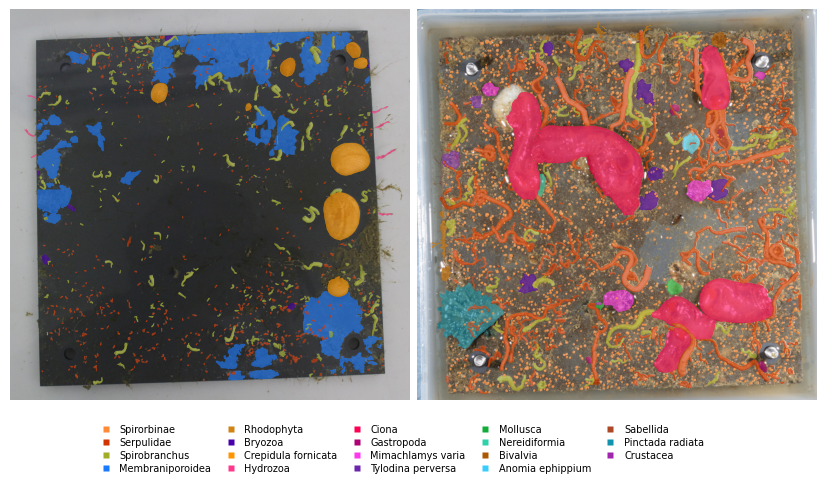

Belgium: ARMS_BelgiumCoast_AJJC86_20200506_20201012_3574117
   4864x3328 px, 20 tiles, 795 annotations, 6 classes
Crete: 712183829_ARMS_1HERP_20200903_20210625_3B_002
   5629x3787 px, 24 tiles, 2212 annotations, 16 classes
legend shows 19 of 19 classes drawn: Spirorbinae, Serpulidae, Spirobranchus, Membraniporoidea, Rhodophyta, Bryozoa, Crepidula fornicata, Hydrozoa, Ciona, Gastropoda, Mimachlamys varia, Tylodina perversa, Mollusca, Nereidiformia, Bivalvia, Anomia ephippium, Sabellida, Pinctada radiata, Crustacea


In [2]:
# plate_tiles.pdf_tex: one panel per site with the annotations and, optionally, the 1024 tile
# grid drawn under them. Colours come from the dataset's class_colors.json; the legend lists
# every class on either plate (LEG_SHARED_ONLY keeps only the shared ones).
# The view is cropped to the annotated area plus ZOOM_PAD. SAME_CROP expands each plate's crop to
# a common aspect ratio rather than a common pixel size, because the sites were photographed at
# different resolutions (4864x3328 and 5629x3787).
# Red bands mark where the last tile column and row overlap their neighbours.
SHOW_GRID    = False    # tile outlines
SHOW_OVERLAP = False    # red bands on the doubled column and row (ignored if SHOW_GRID is False)
PLATES  = {"Belgium": None,   # None -> busiest_plate(site); or pin a stem string
           "Crete": "712183829_ARMS_1HERP_20200903_20210625_3B_002"}
MAX_PX, PANEL_W, WGAP = 1400, 5.2, 0.02   # display px, panel width in inches, gap between panels
ZOOM_PAD = 0.04                           # margin around the annotated area, fraction of its size
SAME_CROP = True                          # one crop SHAPE for both panels (see the note above)
STRETCH   = True                          # fill each panel edge to edge (with SAME_CROP this
                                          # stretches by almost nothing); False keeps proportions
ALPHA    = 0.60                           # polygon fill opacity. 1 = solid, 0.3 = see the photo
EDGE_LW  = 0.3                            # polygon outline width; raise it if fills are faint
LEG_FS, LEG_NCOL, LEG_GAP = 7, 5, 0.03    # legend text size, columns, gap below the panels
LEG_SHARED_ONLY = False                   # True -> only classes found on both plates

_PAL = json.load(open(ROOT / "class_colors.json"))
def _col(cname):
    rgb = _PAL.get(cname)
    return tuple(v / 255 for v in rgb) if rgb else GRAY

def _draw_all(ax, anns, k, lw=EDGE_LW, alpha=ALPHA):
    """Every class in its own colour, nothing bucketed. Returns the per-class counts."""
    present = Counter()
    for a in anns:
        c = catname[a["category_id"]]
        present[c] += 1
        for seg in a["segmentation"]:
            pts = np.array(seg, float).reshape(-1, 2) * k
            if len(pts) >= 3:
                ax.add_patch(plt.Polygon(pts, closed=True, fc=_col(c), ec=_col(c),
                                         lw=lw, alpha=alpha))
    return present

def _ann_box(anns, pad=ZOOM_PAD):
    """Box around every annotation in ORIGINAL plate pixels, padded. Kept in source pixels so
    the two sites can be given a common size; k differs per site and display pixels cannot be
    compared across panels."""
    pts = np.concatenate([np.array(s, float).reshape(-1, 2)
                          for a in anns for s in a["segmentation"] if len(s) >= 6])
    (x0, y0), (x1, y1) = pts.min(0), pts.max(0)
    m = pad * max(x1 - x0, y1 - y0)
    return x0 - m, y0 - m, x1 + m, y1 + m

def _to_aspect(box, ar, W, H):
    """Grow a box about its centre until height/width == ar, then slide it inside the image.
    Only ever grows, so no annotation is cropped out."""
    x0, y0, x1, y1 = box
    w, h = x1 - x0, y1 - y0
    if h / w < ar:
        h = w * ar
    else:
        w = h / ar
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    w, h = min(w, W), min(h, H)
    nx = min(max(0, cx - w / 2), W - w)
    ny = min(max(0, cy - h / 2), H - h)
    return nx, ny, nx + w, ny + h

info, counts = {}, {}
for site, pin in PLATES.items():
    stem = pin or busiest_plate(site)
    disp, k, W, H = plate_scaled(site, stem, MAX_PX)
    anns = plate_anns(site, stem)
    info[site] = [stem, disp, k, W, H, anns, tile_origins(site, stem), _ann_box(anns)]

if SAME_CROP:                                   # one SHAPE for every panel
    _ar = max((b[3] - b[1]) / (b[2] - b[0]) for *_x, b in info.values())
    for site, v in info.items():
        v[7] = _to_aspect(v[7], _ar, v[3], v[4])
for site, v in info.items():                    # source px -> display px, per site
    k = v[2]
    v[7] = tuple(c * k for c in v[7])

ar = max((b[3] - b[1]) / (b[2] - b[0]) for *_x, b in info.values())   # tallest cropped panel
fig, axes = plt.subplots(1, len(info), figsize=(PANEL_W * len(info), PANEL_W * ar),
                         gridspec_kw=dict(wspace=WGAP))
for ax, (site, (stem, disp, k, W, H, anns, origins, ext)) in zip(np.atleast_1d(axes), info.items()):
    ax.imshow(disp); nobox(ax)
    if SHOW_GRID:
        draw_tiles(ax, origins, k, show_overlap=SHOW_OVERLAP)
    counts[site] = _draw_all(ax, anns, k)
    ax.set_xlim(ext[0], ext[2]); ax.set_ylim(ext[3], ext[1])   # y inverted: imshow origin is upper
    if STRETCH:
        # aspect 'auto' so both images fill identical axes ('equal' would letterbox them)
        ax.set_aspect("auto")

# legend: every class drawn, or just the common ones if LEG_SHARED_ONLY, no counts
_sets = [set(c) for c in counts.values()]
shared = sorted(set.intersection(*_sets) if LEG_SHARED_ONLY else set.union(*_sets),
                key=lambda c: -sum(counts[s].get(c, 0) for s in counts))
handles = [plt.Line2D([], [], marker="s", ls="", ms=5, mfc=_col(c), mec="none", label=c)
           for c in shared]
# anchor the legend to the panel bottoms (get_position), not the figure bottom
_bot = min(a.get_position().y0 for a in np.atleast_1d(axes))
fig.legend(handles=handles, fontsize=LEG_FS, ncol=LEG_NCOL, frameon=False,
           loc="upper center", bbox_to_anchor=(.5, _bot - LEG_GAP),
           handletextpad=0.4, columnspacing=1.0, labelspacing=0.3)
save_pdf_tex(fig, "plate_tiles")
plt.show()

for site, (stem, _d, _k, W, H, anns, org, ext) in info.items():
    print(f"{site}: {stem}\n   {W}x{H} px, {len(org)} tiles, {len(anns)} annotations, "
          f"{len(counts[site])} classes")
print(f"legend shows {len(shared)} of "
      f"{len(set().union(*[set(c) for c in counts.values()]))} classes drawn"
      f"{' (shared by both plates)' if LEG_SHARED_ONLY else ''}: {', '.join(shared)}")


wrote plate_raw_vs_annotated.pdf + plate_raw_vs_annotated.pdf_tex


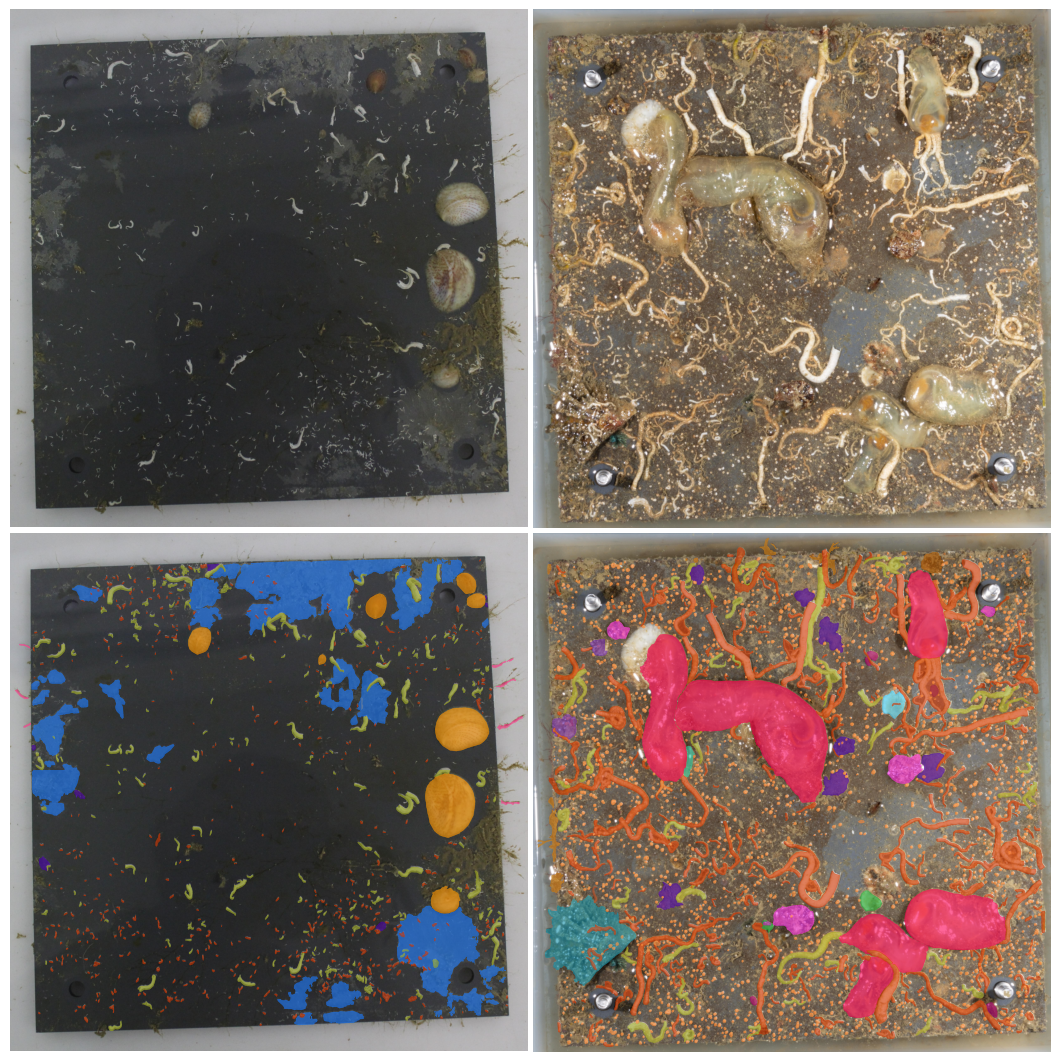

Belgium: ARMS_BelgiumCoast_AJJC86_20200506_20201012_3574117
   4864x3328 px, 795 annotations, 6 classes
Crete: 712183829_ARMS_1HERP_20200903_20210625_3B_002
   5629x3787 px, 2212 annotations, 16 classes


In [3]:
# plate_raw_vs_annotated.pdf_tex: 2x2, the bare plate above and every instance filled in its
# class colour below, i.e. what an annotator has to produce from the photo. The crop is computed
# once per site and used for both rows so they line up. Uses the helpers from the cell above
# (_col, _draw_all, _ann_box, _to_aspect), so run that first.
PLATES2   = PLATES            # same plates as plate_tiles; pin other stems here to change them
MAX_PX2   = 1400              # display px on the long side
PANEL_W2  = 5.2               # width of ONE panel in inches
WGAP2, HGAP2 = 0.01, 0.01     # gap between the columns, gap between the photo and annotation row
ZOOM_PAD2 = 0.01              # margin around the annotated area, fraction of its size
SAME_CROP2 = True             # one crop SHAPE for every panel
STRETCH2   = True             # fill each panel edge to edge so all four render the same size
ALPHA2     = 0.60             # polygon fill opacity on the bottom row
EDGE_LW2   = 0.3              # polygon outline width
# LaTeX typesets the legend text, so matplotlib only reserves its space: sized for the LaTeX
# font after the 10.4in figure is scaled to a 6.3in \linewidth
LEG_FS2, LEG_NCOL2 = 13, 4    # reserved text size and columns (\scriptsize in the LaTeX figure)
LEG_GAP2   = 0.006            # gap from the panel bottoms to the legend, tighter than plate_tiles
LEG_BAND2  = 0.13             # figure height reserved for the legend, as a fraction

info2 = {}
for site, pin in PLATES2.items():
    stem = pin or busiest_plate(site)
    disp, k, W, H = plate_scaled(site, stem, MAX_PX2)
    anns = plate_anns(site, stem)
    info2[site] = [stem, disp, k, W, H, anns, _ann_box(anns, ZOOM_PAD2)]

if SAME_CROP2:                                  # one SHAPE for every panel
    _ar2 = max((b[3] - b[1]) / (b[2] - b[0]) for *_x, b in info2.values())
    for v in info2.values():
        v[6] = _to_aspect(v[6], _ar2, v[3], v[4])
for v in info2.values():                        # source px -> display px, per site
    v[6] = tuple(c * v[2] for c in v[6])

ar2 = max((b[3] - b[1]) / (b[2] - b[0]) for *_x, b in info2.values())   # tallest cropped panel
# the panels keep their own height and the legend band is added on top of it, so reserving the
# band cannot squash the plates
fig, axes = plt.subplots(2, len(info2),
                         figsize=(PANEL_W2 * len(info2),
                                  PANEL_W2 * ar2 * 2 / (1 - LEG_BAND2)),
                         gridspec_kw=dict(wspace=WGAP2, hspace=HGAP2))
axes = np.atleast_2d(axes).reshape(2, len(info2))

counts2 = {}                                    # filled by _draw_all on the bottom row
# save_pdf_tex doesn't crop, so pin the subplots to the figure edges; otherwise the default
# margins end up in the PDF and the plates fill only ~78% of \linewidth
fig.subplots_adjust(left=0, right=1, bottom=LEG_BAND2, top=1, wspace=WGAP2, hspace=HGAP2)
for col, (site, (stem, disp, k, W, H, anns, ext)) in enumerate(info2.items()):
    for row in range(2):                        # 0 = photo only, 1 = the same view annotated
        ax = axes[row, col]
        ax.imshow(disp); nobox(ax)
        if row:
            counts2[site] = _draw_all(ax, anns, k, lw=EDGE_LW2, alpha=ALPHA2)
        ax.set_xlim(ext[0], ext[2]); ax.set_ylim(ext[3], ext[1])   # y inverted, imshow origin upper
        if STRETCH2:
            # aspect 'auto', as in the cell above
            ax.set_aspect("auto")

# legend: every class drawn on either plate, no counts, exactly as in plate_tiles above
_sets2 = [set(c) for c in counts2.values()]
shared2 = sorted(set.intersection(*_sets2) if LEG_SHARED_ONLY else set.union(*_sets2),
                 key=lambda c: -sum(counts2[s].get(c, 0) for s in counts2))
handles2 = [plt.Line2D([], [], marker="s", ls="", ms=5, mfc=_col(c), mec="none", label=c)
            for c in shared2]
# anchored to the panel bottoms, as in the cell above
_bot2 = min(a.get_position().y0 for a in axes.ravel())
fig.legend(handles=handles2, fontsize=LEG_FS2, ncol=LEG_NCOL2, frameon=False,
           loc="upper center", bbox_to_anchor=(.5, _bot2 - LEG_GAP2),
           handletextpad=0.4, columnspacing=1.0, labelspacing=0.3)
save_pdf_tex(fig, "plate_raw_vs_annotated")
plt.show()

for site, (stem, _d, _k, W, H, anns, ext) in info2.items():
    print(f"{site}: {stem}\n   {W}x{H} px, {len(anns)} annotations, "
          f"{len({catname[a['category_id']] for a in anns})} classes")


### qualitative results


tiles: ['0201012_3574139_x3072_y0', '0201012_3574079_x3072_y0', '1012_3574139_x1024_y1024']
<All keys matched successfully>
  0201012_3574139_x3072_y0  n=  6  box= 81.7  click= 80.6  yolo=  8.0  (dets=7)
  0201012_3574079_x3072_y0  n= 14  box= 72.8  click= 62.2  yolo= 35.8  (dets=10)
  1012_3574139_x1024_y1024  n=  7  box= 75.6  click= 65.4  yolo= 57.7  (dets=9)


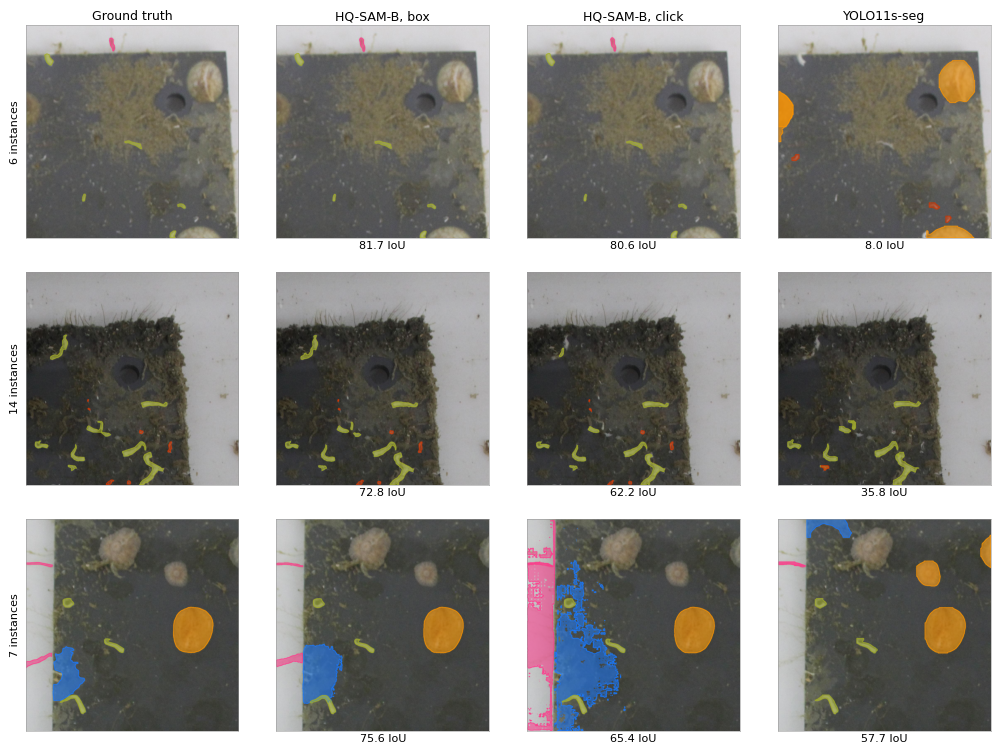

In [6]:
# qualitative.pdf_tex: the same tiles in four columns (annotation, HQ-SAM-B under click and
# under box, and the automatic detector). The box recovers the extent a single click leaves
# ambiguous; the detector misses most organisms outright.
# HQ-SAM-B stands in for SAM2-B+ (within one macro IoU). The detector is YOLO11s-seg because the
# v15 Mask R-CNN weights are gone and its v15 prediction files all hold the Crete evaluation.
# The IoU under each panel is for that tile only (same greedy matching as the tables).
SITE_Q   = "Belgium"
EXP_Q    = BASE / "prepared_v15/shared/species_Belgium"     # test images + prompts
HQ_BASE  = BASE / "code/sam-hq/pretrained_checkpoint/sam_hq_vit_b.pth"
HQ_FT    = BASE / "outputs/v15/gencmp/v11gc_Belgium_hqsam_vit_b/best_hq_58.pth"
YOLO_W   = BASE / "outputs/v15/taskB/yolo/yolo11s-seg_Belgium_i1024/weights/best.pt"
TB_COCO  = BASE / "experiments/taskB_v11/Belgium/test.json"  # detector label order
TILES_Q  = None          # None -> pick automatically (see PICK below); or a list of tile stems
N_ROWS   = 3             # tiles shown
N_RANGE  = (6, 16)       # only consider tiles with this many target instances
PICK     = "spread"      # worst / median / best tile by automatic IoU
CONF_Q   = 0.25          # YOLO confidence, the ultralytics default
CELL_Q, ALPHA_Q = 2.6, 0.55

import sys, cv2, torch
from pycocotools import mask as maskutil

_pal_q = json.load(open(ROOT / "class_colors.json"))
_tb    = json.load(open(TB_COCO))
_det   = {c["id"]: c["name"] for c in _tb["categories"]}      # detector idx -> class name
_gtid  = {v: k for k, v in catname.items()}                   # class name -> COCO cat id

def _colq(cid):
    rgb = _pal_q.get(catname.get(cid, ""))
    return np.array(rgb, float) / 255 if rgb else np.array([0.42, 0.42, 0.42])

def _iou(a, b):
    u = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / u) if u else 0.0

_bxd = EXP_Q / "test/prompts_v10/bbox_perfect"
_ckd = EXP_Q / "test/prompts_v10/click_1pt"
_imd = EXP_Q / "test/images"

from ultralytics import YOLO
_yolo = YOLO(str(YOLO_W))

def _auto(stem):
    """YOLO masks for one tile, resized back to the tile grid."""
    r = _yolo.predict(source=str(_imd / f"{stem}.jpg"), imgsz=1024, conf=CONF_Q, verbose=False)[0]
    if r.masks is None:
        return []
    cls = r.boxes.cls.cpu().numpy().astype(int)
    return [(cv2.resize(m, (1024, 1024), interpolation=cv2.INTER_NEAREST) > 0.5,
             _gtid.get(_det.get(int(c), ""), -1))
            for m, c in zip(r.masks.data.cpu().numpy(), cls)]

# ---- choose the tiles ------------------------------------------------------------------------
_pool = [(len(json.load(open(f))["instances"]), f.stem) for f in sorted(_bxd.glob("*.json"))]
_pool = [s for n, s in _pool if N_RANGE[0] <= n <= N_RANGE[1]]
if TILES_Q:
    tiles_q = list(TILES_Q)
else:
    scored = []
    for s in _pool:
        a = _auto(s)
        gts = [maskutil.decode(i["gt_rle"]).astype(bool) for i in json.load(open(_bxd / f"{s}.json"))["instances"]]
        scored.append((np.mean([max((_iou(m, g) for m, _ in a), default=0.0) for g in gts]), s))
    scored.sort()
    idx = [0, len(scored) // 2, len(scored) - 1][:N_ROWS] if PICK == "spread" else range(N_ROWS)
    tiles_q = [scored[i][1] for i in idx]
print("tiles:", [t[-24:] for t in tiles_q])

# ---- HQ-SAM-B, fine-tuned in domain ----------------------------------------------------------
if str((BASE / "code/sam-hq").resolve()) not in sys.path:
    sys.path.insert(0, str((BASE / "code/sam-hq").resolve()))
from segment_anything import sam_model_registry, SamPredictor
_dev = "cuda" if torch.cuda.is_available() else "cpu"
_sam = sam_model_registry["vit_b"](checkpoint=str(HQ_BASE)).to(_dev)
_sam.mask_decoder.load_state_dict(torch.load(str(HQ_FT), map_location=_dev), strict=False)
_sam.eval()
_pred = SamPredictor(_sam)

rows_q = []
for stem in tiles_q:
    img = np.array(Image.open(_imd / f"{stem}.jpg").convert("RGB"))
    H, W = img.shape[:2]
    _pred.set_image(img)
    bx = json.load(open(_bxd / f"{stem}.json"))
    ck = {i["ann_id"]: i for i in json.load(open(_ckd / f"{stem}.json"))["instances"]}
    sx, sy = W / bx["width"], H / bx["height"]

    gt, pb, pc, ib, ic = [], [], [], [], []
    for ins in bx["instances"]:
        g = maskutil.decode(ins["gt_rle"]).astype(bool)
        c = ins["category_id"]
        gt.append((g, c))
        b = np.array(ins["bbox_xyxy"], np.float32) * np.array([sx, sy, sx, sy], np.float32)
        m, _, _ = _pred.predict(box=b[None], multimask_output=False, hq_token_only=True)
        pb.append((m[0].astype(bool), c)); ib.append(_iou(m[0].astype(bool), g))
        ci = ck.get(ins["ann_id"])
        if ci and ci.get("points"):
            p = np.array(ci["points"], np.float32) * np.array([sx, sy], np.float32)
            m, _, _ = _pred.predict(point_coords=p, point_labels=np.array(ci["labels"], np.int32),
                                    multimask_output=False, hq_token_only=True)
            pc.append((m[0].astype(bool), c)); ic.append(_iou(m[0].astype(bool), g))
    au = _auto(stem)
    ia = [max((_iou(m, g) for m, _ in au), default=0.0) for g, _ in gt]
    rows_q.append((img, gt, pb, pc, au, np.mean(ib) * 100, np.mean(ic) * 100, np.mean(ia) * 100))
    print(f"  {stem[-24:]}  n={len(gt):3d}  box={rows_q[-1][5]:5.1f}  "
          f"click={rows_q[-1][6]:5.1f}  yolo={rows_q[-1][7]:5.1f}  (dets={len(au)})")

COLS_Q = ["Ground truth", "HQ-SAM-B, box", "HQ-SAM-B, click", "YOLO11s-seg"]
fig, ax = plt.subplots(len(rows_q), 4, figsize=(4 * CELL_Q, len(rows_q) * CELL_Q), squeeze=False)
for r, (img, gt, pb, pc, au, vb, vc, va) in enumerate(rows_q):
    for c, (masks, val) in enumerate([(gt, None), (pb, vb), (pc, vc), (au, va)]):
        a = ax[r, c]
        over = img.astype(float) / 255
        for m, cid in masks:
            k = _colq(cid)
            over[m] = (1 - ALPHA_Q) * over[m] + ALPHA_Q * k
            # outline as well as fill: at print size a faint fill alone is unreadable
            cs, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(over, cs, -1, tuple(float(v) for v in k), 2)
        a.imshow(over); a.set_xticks([]); a.set_yticks([])
        for sp in a.spines.values():
            sp.set_linewidth(0.4); sp.set_color("0.6")
        if r == 0:
            a.set_title(COLS_Q[c], fontsize=9, pad=4)
        if val is not None:
            a.set_xlabel(f"{val:.1f} IoU", fontsize=8, labelpad=2)
    ax[r, 0].set_ylabel(f"{len(gt)} instances", fontsize=8)
# pin the axes to the figure edges (save_pdf_tex doesn't crop)
fig.subplots_adjust(left=0.035, right=0.995, top=0.945, bottom=0.04, wspace=0.02, hspace=0.16)
# save_pdf_tex(fig, "qualitative")
plt.show()


### qualitative: per-object prompt and model comparison


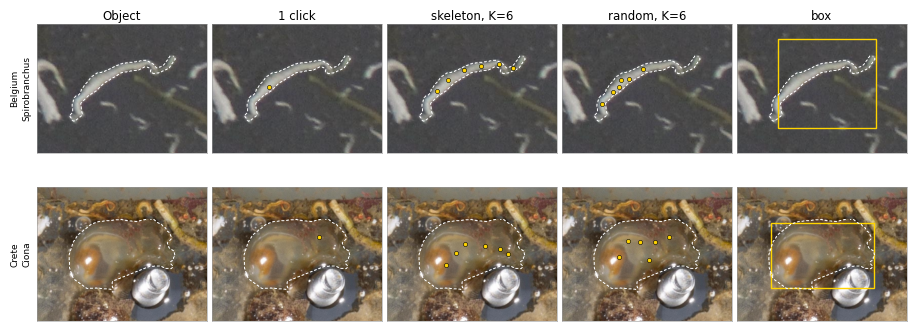

prompt seed 44744  (locked)
  Belgium: Spirobranchus ann_id=3708 on a TEST plate, 4767 px
  Crete: Ciona ann_id=1216 on a TEST plate, 61595 px


In [69]:
# qualitative, stage 1 of 2: draw the prompts (no model is run, so this is instant). When a
# draw looks right, put its seed in SEED_Q; stage 2 uses the same seed and so the same prompts.
SEED_Q  = 44744           # None -> new draw each run; an int -> locked. 42 is the tables' seed
QDIR    = BASE / "outputs/qualitative"
CROP_PAD = 0.30          # padding around the object, as a fraction of its longer side
CELL_P   = 1.85          # panel size in inches
PR_COL   = "#ffd400"     # prompt colour: clicks, skeleton and random points, and the box
PR_MS, PR_MEW, PR_BLW = 9, 0.4, 1.0   # point size, its outline, and the box line width
GT_EDGE  = "white"       # the ground-truth outline, drawn on every panel
OK_COL   = np.array([0.42, 0.84, 0.45])   # agrees with the annotation
BAD_COL  = np.array([0.94, 0.42, 0.42])   # disagrees, in either direction

# plain text, not math: Inkscape's LaTeX export scrambled "$K{=}6$" into "=6K"
PROMPT_COLS = [("click_1pt", "1 click"), ("skely_K6", "skeleton, K=6"),
               ("random_K6", "random, K=6"), ("bbox_noisy", "box")]
MODEL_COLS  = [("sam1", "SAM-1-B"), ("hqsam", "HQ-SAM-B"),  ("sam2", "SAM2-B+"),
               ("osiseg", "OSISeg-B"), ("segnext", "SegNext"), ("simpleclick", "SimpleClick")]
FAMS_Q = [f for f, _ in MODEL_COLS]

import sys, cv2, secrets, subprocess
from matplotlib.patches import Rectangle
from pycocotools import mask as maskutil

_ROOT_Q = BASE.resolve()          # BASE is relative ("..", from notebooks/); a subprocess and
if str(_ROOT_Q / "arms_benchmark") not in sys.path:   # an import both need it absolute
    sys.path.insert(0, str(_ROOT_Q / "arms_benchmark"))
from arms.prompts import build_prompt, CLICK, SKELY, RANDOM, BBOX

_PTYPE = {"click_1pt": (CLICK, None), "skely_K6": (SKELY, 6),
          "random_K6": (RANDOM, 6), "bbox_noisy": (BBOX, None)}
_tg = json.load(open(QDIR / "targets.json"))
_pal_qq = json.load(open(ROOT / "class_colors.json"))
SITES_Q = list(_tg)
seed_q = SEED_Q if SEED_Q is not None else secrets.randbelow(100000)

def _gt_of(site):
    t = _tg[site]
    coco = json.load(open(ROOT / f"{site}/full_plate/grid_1024/annotations.coco.json"))
    a = next(x for x in coco["annotations"] if x["id"] == t["ann_id"])
    r = maskutil.frPyObjects(a["segmentation"], t["height"], t["width"])
    return maskutil.decode(maskutil.merge(r)).astype(bool)

def _prompts_of(site):
    """Exactly what scripts/qual_masks.py will build at this seed: one rng per prompt type,
    seeded with seed + ann_id, so the preview is the prompt and not an approximation of it."""
    gt, out = _gt_of(site), {}
    for nm, (pt, K) in _PTYPE.items():
        p = build_prompt(gt, pt, np.random.default_rng(seed_q + _tg[site]["ann_id"]), K=K)
        if p is None:
            continue
        out[nm] = ({"points": p["point_coords"].tolist(), "labels": p["point_labels"].tolist()}
                   if p["point_coords"] is not None else {"bbox_xyxy": p["box"].tolist()})
    return gt, out

def _crop_box(gt):
    ys, xs = np.nonzero(gt)
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    m = CROP_PAD * max(x1 - x0, y1 - y0)
    H, W = gt.shape
    return (int(max(0, x0 - m)), int(min(W, x1 + m)),
            int(max(0, y0 - m)), int(min(H, y1 + m)))

def _outline(ax, m, box, colour, lw=0.7, dashed=True):
    x0, y0 = box[0], box[2]
    cs, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in cs:
        p = c.reshape(-1, 2)
        ax.plot(p[:, 0] - x0, p[:, 1] - y0, color=colour, lw=lw,
                ls=(0, (3, 2)) if dashed else "-")

def _prompt_on(ax, box, prompt):
    if not prompt:
        return
    x0, y0 = box[0], box[2]
    if "bbox_xyxy" in prompt:
        bx0, by0, bx1, by1 = prompt["bbox_xyxy"]
        ax.add_patch(Rectangle((bx0 - x0, by0 - y0), bx1 - bx0, by1 - by0,
                               fill=False, ec=PR_COL, lw=PR_BLW))
    elif prompt.get("points"):
        p = np.array(prompt["points"], float)
        ax.scatter(p[:, 0] - x0, p[:, 1] - y0, s=PR_MS, c=PR_COL,
                   edgecolors="black", linewidths=PR_MEW, zorder=3)

def _bare(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.4); s.set_color("0.6")

_stage1 = {}
fig, ax = plt.subplots(len(SITES_Q), len(PROMPT_COLS) + 1,
                       figsize=((len(PROMPT_COLS) + 1) * CELL_P, len(SITES_Q) * CELL_P),
                       squeeze=False)
for r, site in enumerate(SITES_Q):
    t = _tg[site]
    img = np.array(Image.open(t["image_path"]).convert("RGB"))
    gt, prm = _prompts_of(site)
    box = _crop_box(gt)
    _stage1[site] = (img, gt, prm, box)
    for c in range(len(PROMPT_COLS) + 1):
        a = ax[r, c]
        a.imshow(img[box[2]:box[3], box[0]:box[1]])
        _outline(a, gt, box, GT_EDGE)
        _bare(a)
        if c:
            _prompt_on(a, box, prm.get(PROMPT_COLS[c - 1][0]))
        if r == 0:
            a.set_title("Object" if c == 0 else PROMPT_COLS[c - 1][1], fontsize=8.5, pad=3)
    ax[r, 0].set_ylabel(f'{site}\n{t["class"]}', fontsize=6.5, linespacing=1.5)
fig.subplots_adjust(left=0.055, right=0.995, top=0.90, bottom=0.03, wspace=0.03, hspace=0.06)
plt.show()

print(f"prompt seed {seed_q}" + ("  (locked)" if SEED_Q is not None else
      f"\n  -> happy with this placement? set SEED_Q = {seed_q} above, then run stage 2"))
for site in SITES_Q:
    t = _tg[site]
    print(f'  {site}: {t["class"]} ann_id={t["ann_id"]} on a {t["split"].upper()} plate, '
          f'{int(_stage1[site][1].sum())} px')


[qual] running sam1 hqsam sam2 osiseg segnext simpleclick at seed 44744
[reroll] sam1 seed=44744


/share/home/e2406747/.conda/envs/torch-arms/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/share/home/e2406747/.conda/envs/torch-arms/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/share/castor/home/e2406747/axolotl/code/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_224 in registry with segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/share/castor/home/e2406747/axol

loaded sam1 ckpt: best_sam1_69.pth
  Belgium  click_1pt    IoU= 72.0
loaded sam1 ckpt: best_sam1_93.pth
  Crete    click_1pt    IoU=  3.8
-> /share/castor/home/e2406747/axolotl/outputs/qualitative/masks_sam1_s44744.npz
[reroll] hqsam seed=44744


/share/home/e2406747/.conda/envs/torch-arms/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/share/home/e2406747/.conda/envs/torch-arms/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/share/castor/home/e2406747/axolotl/code/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_224 in registry with segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/share/castor/home/e2406747/axol

<All keys matched successfully>
loaded hqsam ckpt: best_hq_58.pth
  Belgium  click_1pt    IoU= 73.7
  Belgium  skely_K6     IoU= 78.8
  Belgium  random_K6    IoU= 73.6
  Belgium  bbox_noisy   IoU= 77.7
<All keys matched successfully>
loaded hqsam ckpt: best_hq_93.pth
  Crete    click_1pt    IoU= 84.9
  Crete    skely_K6     IoU= 87.7
  Crete    random_K6    IoU= 86.9
  Crete    bbox_noisy   IoU= 85.1
-> /share/castor/home/e2406747/axolotl/outputs/qualitative/masks_hqsam_s44744.npz
[reroll] sam2 seed=44744


...

  Belgium  click_1pt    IoU= 50.4
loaded segnext: best.pth (113.8M params)
  Crete    click_1pt    IoU= 71.8
-> /share/castor/home/e2406747/axolotl/outputs/qualitative/masks_segnext_s44744.npz
[reroll] simpleclick seed=44744


/share/home/e2406747/.conda/envs/simpleclick/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/share/home/e2406747/.conda/envs/simpleclick/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


loaded simpleclick: best.pth (98.0M params, zoom_in={'skip_clicks': -1, 'target_size': (448, 448)})


/share/home/e2406747/.conda/envs/simpleclick/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


  Belgium  click_1pt    IoU= 58.7
loaded simpleclick: best.pth (98.0M params, zoom_in={'skip_clicks': -1, 'target_size': (448, 448)})
  Crete    click_1pt    IoU= 66.3
-> /share/castor/home/e2406747/axolotl/outputs/qualitative/masks_simpleclick_s44744.npz
wrote qual_prompts.pdf + qual_prompts.pdf_tex


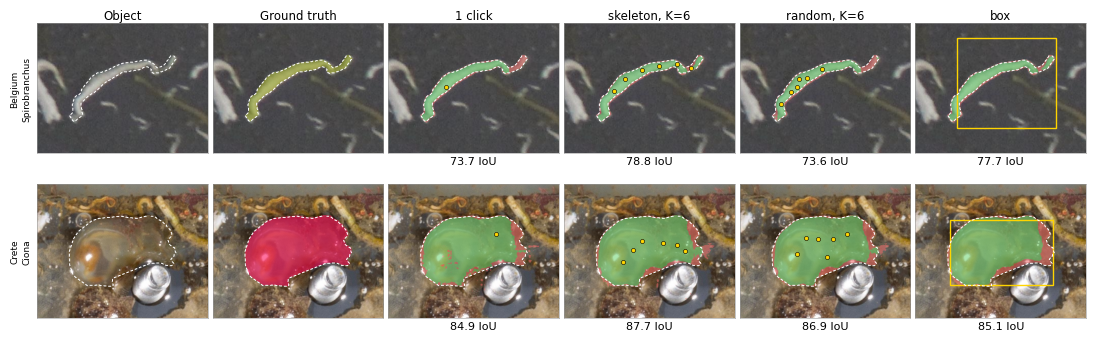

wrote qual_models.pdf + qual_models.pdf_tex


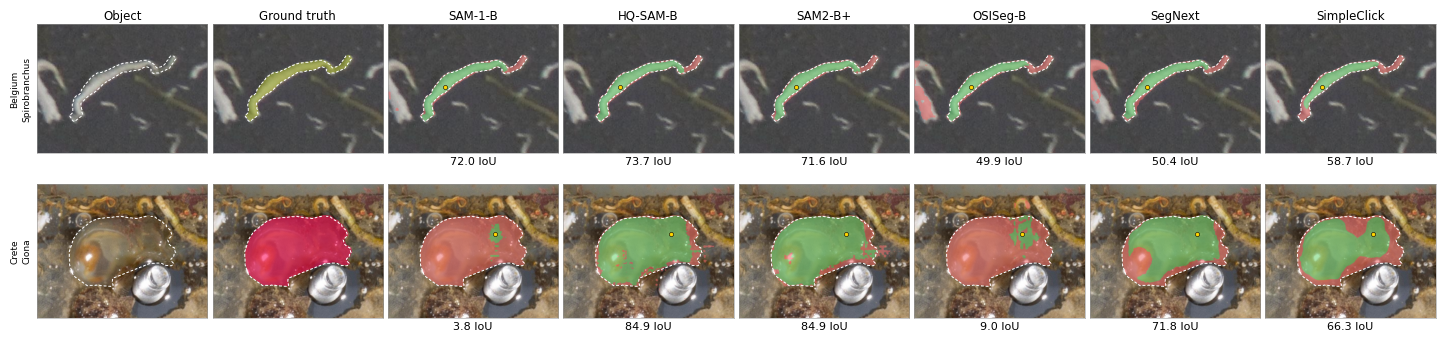


seed 44744 (locked)
  Belgium: Spirobranchus
    prompts {'1 click': 73.7, 'skeleton, K=6': 78.8, 'random, K=6': 73.6, 'box': 77.7}
    models  {'SAM-1-B': 72.0, 'HQ-SAM-B': 73.7, 'SAM2-B+': 71.6, 'OSISeg-B': 49.9, 'SegNext': 50.4, 'SimpleClick': 58.7}
  Crete: Ciona
    prompts {'1 click': 84.9, 'skeleton, K=6': 87.7, 'random, K=6': 86.9, 'box': 85.1}
    models  {'SAM-1-B': 3.8, 'HQ-SAM-B': 84.9, 'SAM2-B+': 84.9, 'OSISeg-B': 9.0, 'SegNext': 71.8, 'SimpleClick': 66.3}
  seeds on disk: [42, 12253, 32843, 40268, 44744, 86984]


In [70]:
# qualitative, stage 2 of 2: run the models at the seed from stage 1.
# Writes qual_prompts.pdf_tex (HQ-SAM-B under the four prompt types, Figure 4.2) and
# qual_models.pdf_tex (the six interactive models under one click, Figure 4.1), both starting
# from an "Object" panel with only the annotation outlined.
# Green = prediction and annotation agree, red = either one alone; the green share is the IoU
# printed below. Masks come from scripts/qual_reroll.sh (the models need different conda envs),
# cached per seed in outputs/qualitative/masks_<family>_s<seed>.npz; each model uses its
# in-domain checkpoint.
assert SEED_Q is not None, "run stage 1, pick a draw, and set SEED_Q to its seed first"

missing = [f for f in FAMS_Q if not (QDIR / f"masks_{f}_s{seed_q}.npz").exists()]
if missing:
    print(f"[qual] running {' '.join(missing)} at seed {seed_q}")
    subprocess.run(["bash", str(_ROOT_Q / "scripts/qual_reroll.sh"), str(seed_q), *missing],
                   check=True, cwd=str(_ROOT_Q))
_npz = {f: np.load(QDIR / f"masks_{f}_s{seed_q}.npz", allow_pickle=True) for f in FAMS_Q}

def _read(fam, site, nm):
    d = _npz.get(fam)
    if d is None or f"{site}/{nm}" not in d.files:
        return None, 0.0, None
    return (d[f"{site}/{nm}"].astype(bool), float(d[f"{site}/{nm}/iou"]),
            json.loads(str(d[f"{site}/{nm}/prompt"])))

def _err_panel(ax, img, box, pred, gt, prompt=None):
    """Agreement in green, disagreement in red. green / (green + red) is the printed IoU."""
    over = img.astype(float) / 255
    ok = pred & gt
    bad = (pred | gt) & ~ok
    over[ok] = 0.45 * over[ok] + 0.55 * OK_COL
    over[bad] = 0.45 * over[bad] + 0.55 * BAD_COL
    ax.imshow(over[box[2]:box[3], box[0]:box[1]])
    _outline(ax, gt, box, GT_EDGE)
    _prompt_on(ax, box, prompt)
    _bare(ax)

def _figure(cols, getter, name):
    # one context column: "Object" already shows the ground-truth outline
    fig, ax = plt.subplots(len(SITES_Q), len(cols) + 1,
                           figsize=((len(cols) + 1) * CELL_P, len(SITES_Q) * CELL_P), squeeze=False)
    for r, site in enumerate(SITES_Q):
        img, gt, _, box = _stage1[site]

        ax[r, 0].imshow(img[box[2]:box[3], box[0]:box[1]])       # the object, outline only
        _outline(ax[r, 0], gt, box, GT_EDGE); _bare(ax[r, 0])
        if r == 0:
            ax[r, 0].set_title("Object", fontsize=8.5, pad=3)
        for c, (key, lbl) in enumerate(cols, start=1):
            m, iou, prm = getter(site, key)
            if m is None:
                ax[r, c].imshow(img[box[2]:box[3], box[0]:box[1]]); _bare(ax[r, c])
            else:
                _err_panel(ax[r, c], img, box, m, gt, prm)
            if r == 0:
                ax[r, c].set_title(lbl, fontsize=8.5, pad=4)
            ax[r, c].set_xlabel("n/a" if m is None else f"{iou:.1f} IoU", fontsize=8, labelpad=13)
    fig.subplots_adjust(left=0.001, right=0.999, top=0.915, bottom=0.075, wspace=0.004, hspace=0.34)
    save_pdf_tex(fig, name)
    plt.show()

_figure(PROMPT_COLS, lambda s, k: _read("hqsam", s, k),     "qual_prompts")
_figure(MODEL_COLS,  lambda s, k: _read(k, s, "click_1pt"), "qual_models")

print(f"\nseed {seed_q} (locked)")
for site in SITES_Q:
    print(f'  {site}: {_tg[site]["class"]}')
    print("    prompts", {l: round(_read("hqsam", site, k)[1], 1) for k, l in PROMPT_COLS})
    print("    models ", {l: round(_read(k, site, "click_1pt")[1], 1) for k, l in MODEL_COLS})
print("  seeds on disk:", sorted({int(f.stem.split("_s")[-1]) for f in QDIR.glob("masks_hqsam_s*.npz")}))


### qualitative: detectors vs interactive

Five columns on the same tiles: the expert annotation, the two automatic detectors, and the two interactive models under the perfect box. Two stages, so the tiles can be chosen before any model is loaded.

In [ ]:
# detectors vs interactive, stage 1 of 2: pick the tiles (no model is run). Each thumbnail is
# the annotation on one test tile; put the indices you want in TILES_D and run stage 2.
SITE_D   = "Belgium"
N_SHOW   = 12            # thumbnails offered
N_RANGE_D = (6, 16)      # only tiles holding this many target instances
GRID_D   = 6             # thumbnails per row
TILES_D  = None          # None -> stage 2 uses the first N_ROWS_D of the pool; or e.g. [0, 4, 9]
N_ROWS_D = 3             # tiles drawn in stage 2
CELL_D, ALPHA_D = 2.6, 0.55

import sys, json, cv2
import numpy as np
from PIL import Image
from pycocotools import mask as maskutil

EXP_D = BASE / f"prepared_v15/shared/species_{SITE_D}"
_bxD  = EXP_D / "test/prompts_v10/bbox_perfect"
_imD  = EXP_D / "test/images"
_palD = json.load(open(ROOT / "class_colors.json"))

def _colD(cid, palette=None, name=None):
    """Fill colour for one instance. Species panels key off catname, phylum panels pass a name."""
    key = name if name is not None else catname.get(cid, "")
    rgb = (palette or _palD).get(key)
    return np.array(rgb, float) / 255 if rgb else np.array([0.42, 0.42, 0.42])

def _iouD(a, b):
    u = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / u) if u else 0.0

def _paint(img, masks, palette=None, alpha=ALPHA_D):
    """Fill + outline. Most organisms are a few dozen pixels across, so the fill alone is not
    readable once the tile is printed a few cm wide."""
    over = img.astype(float) / 255
    for m, cid, nm in masks:
        k = _colD(cid, palette, nm)
        over[m] = (1 - alpha) * over[m] + alpha * k
        cs, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(over, cs, -1, tuple(float(v) for v in k), 2)
    return over

def _gt_of(stem):
    """(mask, category_id, None) per annotated instance on one tile."""
    return [(maskutil.decode(i["gt_rle"]).astype(bool), i["category_id"], None)
            for i in json.load(open(_bxD / f"{stem}.json"))["instances"]]

# ---- the pool, ordered so the offer is stable between runs ------------------------------------
POOL_D = sorted(s for n, s in
                ((len(json.load(open(f))["instances"]), f.stem) for f in sorted(_bxD.glob("*.json")))
                if N_RANGE_D[0] <= n <= N_RANGE_D[1])
print(f"{len(POOL_D)} tiles at {SITE_D} hold {N_RANGE_D[0]}-{N_RANGE_D[1]} instances; showing {N_SHOW}")

_show = POOL_D[:N_SHOW]
_nr = int(np.ceil(len(_show) / GRID_D))
fig, ax = plt.subplots(_nr, GRID_D, figsize=(GRID_D * 2.0, _nr * 2.0), squeeze=False)
for a in ax.ravel():
    a.axis("off")
for j, stem in enumerate(_show):
    a = ax[j // GRID_D, j % GRID_D]
    g = _gt_of(stem)
    a.imshow(_paint(np.array(Image.open(_imD / f"{stem}.jpg").convert("RGB")), g))
    a.set_title(f"[{j}]  {len(g)} inst", fontsize=8, pad=2)   # index for picking, not a tile id
fig.suptitle("pick indices -> TILES_D, then run stage 2", fontsize=9, y=1.0)
fig.tight_layout()
plt.show()

In [ ]:
# detectors vs interactive, stage 2 of 2: annotation, the two detectors, and HQ-SAM-B and
# SAM2-B+ given the same perfect box. The detectors miss organisms outright; the interactive
# models only have to outline the object they are given.
# Mask R-CNN comes from the outputs/v16tb retrain, since the v15 weights are gone and its v15
# prediction files all hold the Crete evaluation.
MRCNN_W  = BASE / f"outputs/v16tb/taskB/maskrcnn/{SITE_D}_i1024/model_best.pth"
YOLO26_W = BASE / f"outputs/v15/taskB/yolo/yolo26s-seg_{SITE_D}_i1024/weights/best.pt"
SAM2_FT  = BASE / f"outputs/v15/gencmp/v11gc_{SITE_D}_sam2_hiera_b"
HQ_FT_D  = BASE / f"outputs/v15/gencmp/v11gc_{SITE_D}_hqsam_vit_b"
HQ_BASE_D = BASE / "code/sam-hq/pretrained_checkpoint/sam_hq_vit_b.pth"
TB_COCO_D = BASE / f"experiments/taskB_v11/{SITE_D}/test.json"
CONF_D   = 0.25          # ultralytics default
IMGSZ_D  = 1024

import os, torch
_ROOT_V = BASE.resolve()          # BASE is relative ("..") from notebooks/; imports need absolute
tiles_d = [POOL_D[i] for i in (TILES_D if TILES_D is not None else range(N_ROWS_D))]
_dev = "cuda" if torch.cuda.is_available() else "cpu"
_tbD  = json.load(open(TB_COCO_D))
_detD = {c["id"]: c["name"] for c in _tbD["categories"]}      # detector index -> class name
_gtidD = {v: k for k, v in catname.items()}                   # class name -> COCO category id
_names_d = [_detD[i] for i in sorted(_detD)]

# ---- automatic 1: Mask R-CNN ------------------------------------------------------------------
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
_cfg = get_cfg()
_cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
_cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(_names_d)
_cfg.INPUT.MIN_SIZE_TEST = IMGSZ_D          # i1024: the tile goes in as-is, no rescale
_cfg.INPUT.MAX_SIZE_TEST = IMGSZ_D
_cfg.MODEL.WEIGHTS = str(MRCNN_W)
_cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = CONF_D
_cfg.MODEL.DEVICE = _dev
_mrcnn = DefaultPredictor(_cfg)

def _run_mrcnn(stem):
    img = cv2.imread(str(_imD / f"{stem}.jpg"))               # detectron2 wants BGR
    inst = _mrcnn(img)["instances"].to("cpu")
    if len(inst) == 0:
        return []
    return [(m.numpy().astype(bool), _gtidD.get(_detD.get(int(c), ""), -1), None)
            for m, c in zip(inst.pred_masks, inst.pred_classes)]

# ---- automatic 2: YOLO26s-seg -----------------------------------------------------------------
from ultralytics import YOLO
_y26 = YOLO(str(YOLO26_W))

def _run_yolo(model, stem):
    r = model.predict(source=str(_imD / f"{stem}.jpg"), imgsz=IMGSZ_D, conf=CONF_D, verbose=False)[0]
    if r.masks is None:
        return []
    return [(cv2.resize(m, (1024, 1024), interpolation=cv2.INTER_NEAREST) > 0.5,
             _gtidD.get(_detD.get(int(c), ""), -1), None)
            for m, c in zip(r.masks.data.cpu().numpy(), r.boxes.cls.cpu().numpy().astype(int))]

# ---- interactive 1: HQ-SAM-B ------------------------------------------------------------------
if str((BASE / "code/sam-hq").resolve()) not in sys.path:
    sys.path.insert(0, str((BASE / "code/sam-hq").resolve()))
from segment_anything import sam_model_registry, SamPredictor
_samD = sam_model_registry["vit_b"](checkpoint=str(HQ_BASE_D)).to(_dev)
_samD.mask_decoder.load_state_dict(
    torch.load(str(sorted(HQ_FT_D.glob("best_hq_*.pth"))[-1]), map_location=_dev), strict=False)
_samD.eval()
_hq = SamPredictor(_samD)

# ---- interactive 2: SAM2-B+ -------------------------------------------------------------------
# build_sam2 resolves its config relative to the sam2 root, so chdir around the call
# (as eval/multieval.py::make_sam2 does)
from arms import paths as _P
_s2root = _P.SAM2_ROOT
if str(_s2root) not in sys.path:
    sys.path.insert(0, str(_s2root))
_cwd = os.getcwd(); os.chdir(_s2root)
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
os.chdir(_cwd)
# eval/infer_sam2.predict_one instead of SAM2ImagePredictor.predict: the sam-hq2 predictor
# passes hq_token_only to the plain decoder, which doesn't accept it (same path as the tables)
if str((_ROOT_V / "arms_benchmark/eval").resolve()) not in sys.path:
    sys.path.insert(0, str((_ROOT_V / "arms_benchmark/eval").resolve()))
from infer_sam2 import predict_one as _sam2_predict
os.chdir(_s2root)
_s2model = build_sam2("configs/sam2.1/sam2.1_hiera_b+.yaml",
                      "checkpoints/sam2.1_hiera_base_plus.pt", device=_dev)
_s2 = SAM2ImagePredictor(_s2model)
os.chdir(_cwd)
_s2model.sam_mask_decoder.load_state_dict(
    torch.load(str(sorted(SAM2_FT.glob("best_sam2_*.pth"))[-1]), map_location=_dev))
_s2model.sam_mask_decoder.eval()

# ---- run ---------------------------------------------------------------------------------------
rows_d = []
for stem in tiles_d:
    img = np.array(Image.open(_imD / f"{stem}.jpg").convert("RGB"))
    H, W = img.shape[:2]
    bx = json.load(open(_bxD / f"{stem}.json"))
    sx, sy = W / bx["width"], H / bx["height"]
    gt = _gt_of(stem)
    _hq.set_image(img); _s2.set_image(img)

    hq, s2, i_hq, i_s2 = [], [], [], []
    for ins in bx["instances"]:
        g = maskutil.decode(ins["gt_rle"]).astype(bool)
        c = ins["category_id"]
        b = np.array(ins["bbox_xyxy"], np.float32) * np.array([sx, sy, sx, sy], np.float32)
        m, _, _ = _hq.predict(box=b[None], multimask_output=False, hq_token_only=True)
        hq.append((m[0].astype(bool), c, None)); i_hq.append(_iouD(m[0].astype(bool), g))
        m2 = _sam2_predict(_s2, _s2model, "bbox_perfect",
                           {**ins, "bbox_xyxy": b.tolist()}, _dev)
        m2 = m2.astype(bool) if m2 is not None else np.zeros_like(g)
        s2.append((m2, c, None)); i_s2.append(_iouD(m2, g))

    mr, y2 = _run_mrcnn(stem), _run_yolo(_y26, stem)
    i_mr = [max((_iouD(m, g) for m, _, _ in mr), default=0.0) for g, _, _ in gt]
    i_y2 = [max((_iouD(m, g) for m, _, _ in y2), default=0.0) for g, _, _ in gt]
    rows_d.append((img, gt, mr, y2, s2, hq,
                   np.mean(i_mr) * 100, np.mean(i_y2) * 100, np.mean(i_s2) * 100, np.mean(i_hq) * 100))
    print(f"  n={len(gt):3d}  mrcnn={rows_d[-1][6]:5.1f} ({len(mr)} det)  "
          f"yolo26={rows_d[-1][7]:5.1f} ({len(y2)} det)  sam2={rows_d[-1][8]:5.1f}  hqsam={rows_d[-1][9]:5.1f}")

COLS_D = ["Ground truth", "Mask R-CNN", "YOLO26s-seg", "SAM2-B+, box", "HQ-SAM-B, box"]
fig, ax = plt.subplots(len(rows_d), 5, figsize=(5 * CELL_D, len(rows_d) * CELL_D), squeeze=False)
for r, (img, gt, mr, y2, s2, hq, vm, vy, v2, vh) in enumerate(rows_d):
    for c, (masks, val) in enumerate([(gt, None), (mr, vm), (y2, vy), (s2, v2), (hq, vh)]):
        a = ax[r, c]
        a.imshow(_paint(img, masks)); a.set_xticks([]); a.set_yticks([])
        for sp in a.spines.values():
            sp.set_linewidth(0.4); sp.set_color("0.6")
        if r == 0:
            a.set_title(COLS_D[c], fontsize=9, pad=4)
        if val is not None:
            a.set_xlabel(f"{val:.1f} IoU", fontsize=8, labelpad=2)
    ax[r, 0].set_ylabel(f"{len(gt)} instances", fontsize=8)
fig.subplots_adjust(left=0.035, right=0.995, top=0.945, bottom=0.04, wspace=0.02, hspace=0.16)
# save_pdf_tex(fig, "qualitative_detectors")
plt.show()

### qualitative: species labels vs phylum labels

The same detector, YOLO11s-seg, trained on the eight-class species labels and on the phylum grouping. Same two-stage split.

In [ ]:
# label space, stage 1 of 2: pick the tiles (same picker as the detector figure)
TILES_L  = None          # None -> stage 2 uses the first N_ROWS_L of the pool; or e.g. [1, 5, 8]
N_ROWS_L = 3

_showL = POOL_D[:N_SHOW]
_nrL = int(np.ceil(len(_showL) / GRID_D))
fig, ax = plt.subplots(_nrL, GRID_D, figsize=(GRID_D * 2.0, _nrL * 2.0), squeeze=False)
for a in ax.ravel():
    a.axis("off")
for j, stem in enumerate(_showL):
    a = ax[j // GRID_D, j % GRID_D]
    g = _gt_of(stem)
    a.imshow(_paint(np.array(Image.open(_imD / f"{stem}.jpg").convert("RGB")), g))
    a.set_title(f"[{j}]  {len(g)} inst", fontsize=8, pad=2)
fig.suptitle("pick indices -> TILES_L, then run stage 2", fontsize=9, y=1.0)
fig.tight_layout()
plt.show()

In [ ]:
# label space, stage 2 of 2: YOLO11s-seg trained on species labels and on phylum labels, on the
# same tiles. Ground truth is drawn once, at species level. The two prediction columns use
# different palettes (different vocabularies), so colours don't correspond across them.
# The phylum weights are the rerun with the shared seven-phylum vocabulary (outputs/v16tb).
YOLO11_SPECIES = BASE / f"outputs/v15/taskB/yolo/yolo11s-seg_{SITE_D}_i1024/weights/best.pt"
YOLO11_PHYLUM  = BASE / f"outputs/v16tb/taskB_phylum/yolo/yolo11s-seg_{SITE_D}_i1024/weights/best.pt"
PH_COCO        = BASE / f"experiments/taskB_phylum/{SITE_D}/test.json"
SP_COCO        = BASE / f"experiments/taskB_v11/{SITE_D}/test.json"
IMGSZ_L, CONF_L = 1024, 0.25

# self-contained: runs without the detector figure above
from ultralytics import YOLO
_detL  = {c["id"]: c["name"] for c in json.load(open(SP_COCO))["categories"]}
_gtidL = {v: k for k, v in catname.items()}

def _run_species(model, stem):
    r = model.predict(source=str(_imD / f"{stem}.jpg"), imgsz=IMGSZ_L, conf=CONF_L, verbose=False)[0]
    if r.masks is None:
        return []
    return [(cv2.resize(m, (1024, 1024), interpolation=cv2.INTER_NEAREST) > 0.5,
             _gtidL.get(_detL.get(int(c), ""), -1), None)
            for m, c in zip(r.masks.data.cpu().numpy(), r.boxes.cls.cpu().numpy().astype(int))]

tiles_l = [POOL_D[i] for i in (TILES_L if TILES_L is not None else range(N_ROWS_L))]

# phylum vocabulary and its own palette: class_colors.json is species-level and has no phyla
_phcats = {c["id"]: c["name"] for c in json.load(open(PH_COCO))["categories"]}
_phnames = [_phcats[i] for i in sorted(_phcats)]
_PH_PAL = {n: tuple(int(255 * v) for v in plt.get_cmap("tab10")(i % 10)[:3])
           for i, n in enumerate(_phnames)}
print(f"phylum vocabulary ({len(_phnames)}): {_phnames}")

# species -> phylum from the manifest's parallel target_cat_ids / target_classes (inverting
# category_remap would mislabel classes, since many species share one phylum)
_y11s = YOLO(str(YOLO11_SPECIES))
_y11p = YOLO(str(YOLO11_PHYLUM))

def _run_phylum(stem):
    r = _y11p.predict(source=str(_imD / f"{stem}.jpg"), imgsz=IMGSZ_L, conf=CONF_L, verbose=False)[0]
    if r.masks is None:
        return []
    return [(cv2.resize(m, (1024, 1024), interpolation=cv2.INTER_NEAREST) > 0.5,
             -1, _phcats.get(int(c), ""))
            for m, c in zip(r.masks.data.cpu().numpy(), r.boxes.cls.cpu().numpy().astype(int))]

rows_l = []
for stem in tiles_l:
    img = np.array(Image.open(_imD / f"{stem}.jpg").convert("RGB"))
    gt = _gt_of(stem)
    sp, ph = _run_species(_y11s, stem), _run_phylum(stem)
    i_sp = [max((_iouD(m, g) for m, _, _ in sp), default=0.0) for g, _, _ in gt]
    i_ph = [max((_iouD(m, g) for m, _, _ in ph), default=0.0) for g, _, _ in gt]
    rows_l.append((img, gt, sp, ph, np.mean(i_sp) * 100, np.mean(i_ph) * 100))
    print(f"  n={len(gt):3d}  species={rows_l[-1][4]:5.1f} ({len(sp)} det)  "
          f"phylum={rows_l[-1][5]:5.1f} ({len(ph)} det)")

COLS_L = ["Ground truth", "YOLO11s, species", "YOLO11s, phylum"]
fig, ax = plt.subplots(len(rows_l), 3, figsize=(3 * CELL_D, len(rows_l) * CELL_D), squeeze=False)
for r, (img, gt, sp, ph, vs, vp) in enumerate(rows_l):
    panels = [(gt, None, None), (sp, vs, None), (ph, vp, _PH_PAL)]
    for c, (masks, val, pal) in enumerate(panels):
        a = ax[r, c]
        a.imshow(_paint(img, masks, palette=pal)); a.set_xticks([]); a.set_yticks([])
        for spn in a.spines.values():
            spn.set_linewidth(0.4); spn.set_color("0.6")
        if r == 0:
            a.set_title(COLS_L[c], fontsize=9, pad=4)
        if val is not None:
            a.set_xlabel(f"{val:.1f} IoU", fontsize=8, labelpad=2)
    ax[r, 0].set_ylabel(f"{len(gt)} instances", fontsize=8)
fig.subplots_adjust(left=0.045, right=0.995, top=0.945, bottom=0.04, wspace=0.02, hspace=0.16)
# save_pdf_tex(fig, "qualitative_labelspace")
plt.show()

### tiling: ours vs the shipped patches

In [ ]:
# tiling_vs_patches: why the plates are re-tiled instead of using the dataset's own patches/.
# Left: how many tiles cover each pixel. The shipped 1024 patches step by 768 (Belgium) or 921
# (Crete), so most of a plate is covered 2 or 4 times; our grid steps by 1024 and only the last
# column and row overlap.
# Right: instance counts. An organism in an overlap is copied into every patch that covers it,
# clipped differently each time, with no id linking the copies. Our grid puts each instance in
# one tile by its bbox centre and keeps plate_ann_id.
PLATE_SITE, TILE = "Belgium", 1024

def _origins_ours(site, stem):
    return tile_origins(site, stem)

def _origins_shipped(site, stem):
    p = json.load(open(ROOT / site / "patches/annotations.coco.json"))
    out = []
    for im in p["images"]:
        m = re.match(rf"^{re.escape(stem)}_(\d+)_(\d+)_jpg\.rf\.[0-9a-f]+\.jpg$", im["file_name"])
        if m:
            out.append((int(m.group(1)), int(m.group(2))))
    return sorted(out)

def _coverage(origins, W, H, tile=TILE, step=8):
    """How many tiles cover each pixel, on a coarse grid so it is cheap to draw."""
    cov = np.zeros((H // step + 1, W // step + 1), int)
    for ox, oy in origins:
        cov[oy // step:(oy + tile) // step, ox // step:(ox + tile) // step] += 1
    return cov

stem = busiest_plate(PLATE_SITE)
_im = next(i for i in coco[PLATE_SITE]["images"] if Path(i["file_name"]).stem == stem)
W, H = _im["width"], _im["height"]
ours, shipped = _origins_ours(PLATE_SITE, stem), _origins_shipped(PLATE_SITE, stem)

fig, ax = plt.subplots(1, 3, figsize=(12.4, 3.9),
                       gridspec_kw=dict(wspace=.28))
vmax = 4
for a, (origins, name) in zip(ax[:2], [(ours, f"ours, grid_1024  ({len(ours)} tiles)"),
                                       (shipped, f"shipped patches/  ({len(shipped)} tiles)")]):
    cov = _coverage(origins, W, H)
    im = a.imshow(cov, cmap="YlOrRd", vmin=1, vmax=vmax, interpolation="nearest")
    a.set_title(f"{name}\nmedian coverage {int(np.median(cov[cov > 0]))}x", fontsize=9)
    nobox(a)
# colourbar under the two map panels, clear of the bar chart
cb = fig.colorbar(im, ax=ax[:2], orientation="horizontal", fraction=.05, pad=.04,
                  ticks=range(1, vmax + 1))
cb.set_label("times each pixel of the plate is covered by a tile", fontsize=8)
cb.ax.tick_params(labelsize=7)

# instance counts: plate truth vs shipped patches vs ours
lab, plate_n, ship_n, our_n = [], [], [], []
for s in SITES:
    lab.append(s)
    plate_n.append(len(coco[s]["annotations"]))
    ship_n.append(len(json.load(open(ROOT / s / "patches/annotations.coco.json"))["annotations"]))
    our_n.append(len(grid[s]["annotations"]))
x = np.arange(len(lab)); w = 0.27
for off, vals, c, nm in [(-w, plate_n, GRAY, "real organisms (full plate)"),
                         (0, ship_n, RED, "shipped patches/"),
                         (w, our_n, "#1baf7a", "ours, grid_1024")]:
    b = ax[2].bar(x + off, vals, w, color=c, label=nm)
    ax[2].bar_label(b, fmt="%d", fontsize=7, padding=1)
for i, (pn, sn) in enumerate(zip(plate_n, ship_n)):
    ax[2].annotate(f"{sn / pn:.2f}x", (i, sn), fontsize=8, color=RED, fontweight="bold",
                   ha="center", xytext=(0, 13), textcoords="offset points")
ax[2].set_xticks(x); ax[2].set_xticklabels(lab); ax[2].set_ylabel("annotation entries", fontsize=8)
ax[2].set_title("duplication in the shipped patches", fontsize=9)
ax[2].legend(fontsize=7, frameon=False, loc="upper left")
ax[2].tick_params(labelsize=8); ax[2].grid(axis="y", alpha=.3, ls=":")
ax[2].set_ylim(0, max(ship_n) * 1.25)
plt.show()

for s in SITES:
    sh = json.load(open(ROOT / s / "patches/annotations.coco.json"))
    n_plate, n_ship, n_our = len(coco[s]["annotations"]), len(sh["annotations"]), len(grid[s]["annotations"])
    print(f"{s}: plate {n_plate}  shipped {n_ship} ({n_ship / n_plate:.2f}x)  ours {n_our}  | "
          f"provenance key on patches: {'plate_ann_id' in sh['annotations'][0]}")


### prompts

Belgium  ann 2142  Serpulidae  872 px  39 neighbours  ARMS_BelgiumCoast_AJJC86_20200506_20201012_3574114_x3072_y2048.jpg
to freeze this one:  PICK = ('Belgium', 2142)   seed = 873446190
wrote prompt_types.pdf + prompt_types.pdf_tex


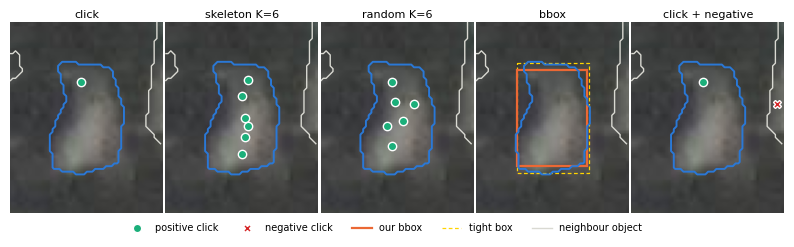

In [71]:
# prompt_types.pdf_tex: every prompt type on one real instance (negative included).
# LAYOUT "row" (1x5, fits \textwidth) or "grid" (3x2, fits \columnwidth). Panels are sized to the
# crop's aspect ratio so HGAP / VGAP of 0 really touch; CELL is the panel height. tight_layout is
# not used because it overrides the gaps.
# Without PICK a new instance is drawn each run, limited to a target class of reasonable size
# with at least three neighbours (so CLICKNEG has a real contact zone). Prompts come from
# arms/prompts.py on the whole tile.
LAYOUT = "row"            # "row" -> 1x5 · "grid" -> 3x2
CELL   = 2.5               # panel HEIGHT in inches; width follows the crop
HGAP   = 0.01              # horizontal gap, fraction of panel width. 0 = touching
VGAP   = 0.12             # vertical gap between rows, fraction of panel height (grid only)
LGAP   = 0.0             # gap from the panels to the legend, in inches
MS     = 6
AREA_RANGE, MIN_NBRS = (800, 60000), 3
PICK = ('Belgium', 2142)  # (site, ann_id) to freeze, or None to draw a new one every run

_rng = np.random.default_rng()                # no seed: a new instance and new prompts every run
if PICK is None:
    cand = [(s, a["id"]) for s in SITES for a in grid[s]["annotations"]
            if catname[a["category_id"]] in TARGET5[s]
            and AREA_RANGE[0] <= a["area"] <= AREA_RANGE[1]
            and sum(1 for b in grid[s]["annotations"]
                    if b["image_id"] == a["image_id"]) - 1 >= MIN_NBRS]
    PICK = cand[_rng.integers(len(cand))]
site, aid = PICK
SHOWN = [("click", CLICK, None), ("skeleton K=6", SKELY, 6), ("random K=6", RANDOM, 6),
         ("bbox", BBOX, None), ("click + negative", CLICKNEG, None)]

ex = load_example(site, aid, pad_frac=0.35)
seed = int(_rng.integers(1 << 30))            # prompt sampling also varies run to run
print(f"{site}  ann {aid}  {ex['cls']}  {ex['px']} px  {len(ex['nbrs'])} neighbours  {ex['tile']}")
print(f"to freeze this one:  PICK = ({site!r}, {aid})   seed = {seed}")

_x0, _y0, _x1, _y1 = ex["win"]
AR = (_x1 - _x0) / (_y1 - _y0)                # crop width / height, so the box fits the image
nr, nc = (1, len(SHOWN)) if LAYOUT == "row" else (3, 2)
fig, ax = plt.subplots(nr, nc, figsize=(CELL * nc * AR, CELL * nr),
                       gridspec_kw=dict(wspace=HGAP, hspace=VGAP if LAYOUT == "grid" else 0))
flat = np.atleast_1d(ax).ravel()
for c, (plabel, ptype, K) in enumerate(SHOWN):
    draw_prompt_real(flat[c], ex, ptype, K, seed=seed, ms=MS)
    flat[c].set_title(plabel, fontsize=8, pad=3)      # column label, not a figure title
for extra in flat[len(SHOWN):]:                       # the 6th cell of the 3x2 stays empty
    extra.set_visible(False)
# class and site are printed above the panels instead of a row label
handles = [plt.Line2D([], [], marker="o", ls="", mfc=POS, mec="w", ms=6, label="positive click"),
           plt.Line2D([], [], marker="X", ls="", mfc=NEG, mec="w", ms=6, label="negative click"),
           plt.Line2D([], [], color=BOX_C, lw=1.6, label="our bbox"),
           plt.Line2D([], [], color=TIGHT, lw=.9, ls=(0, (3, 2)), label="tight box"),
           plt.Line2D([], [], color=NBR, lw=1.0, label="neighbour object")]
fig.legend(handles=handles, fontsize=7, ncol=5 if LAYOUT == "row" else 2, frameon=False,
           loc="lower center", bbox_to_anchor=(.5, -LGAP / (CELL * nr)))
save_pdf_tex(fig, "prompt_types")
plt.show()


Belgium  ann 2142  Serpulidae  872 px  39 neighbours  ARMS_BelgiumCoast_AJJC86_20200506_20201012_3574114_x3072_y2048.jpg
3 seeds: [0, 1, 2]   to freeze this instance:  PICK = ('Belgium', 2142)
wrote prompt_types_seeds.pdf + prompt_types_seeds.pdf_tex


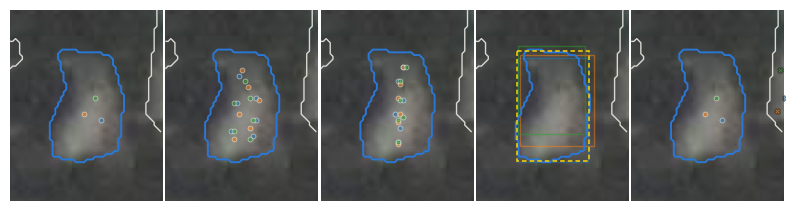

In [75]:
# prompt_types_seeds.pdf_tex: the same instance and panels as above, with several of the
# evaluation's prompt seeds (multieval draws seeds 0-9 with default_rng(seed)) overlaid, so each
# panel shows where a sampler tends to put its points. One colour per seed; the marker shows the
# label (filled circle = positive, cross = negative). With PICK set the figure is reproducible.
# Layout settings as in the cell above.
LAYOUT = "row"            # "row" -> 1x5 · "grid" -> 3x2
CELL   = 2.5              # panel HEIGHT in inches; width follows the crop
HGAP   = 0.01             # horizontal gap, fraction of panel width. 0 = touching
VGAP   = 0.12             # vertical gap between rows, fraction of panel height (grid only)
LGAP   = 0.0              # gap from the panels down to the marker legend, in INCHES
SGAP   = 0.20             # extra gap from the marker legend down to the seed swatches, in INCHES
MS     = 3.5              # smaller than the single-seed figure: ten times as many marks
ALPHA  = 0.5             # per-mark opacity
SEEDS  = range(3)        # evaluation uses seeds 0-9; range(10) shows them all
SCMAP  = "tab10"          # one hue per seed; "viridis" shows seed order as a ramp
AREA_RANGE, MIN_NBRS = (800, 60000), 3
PICK = ('Belgium', 2142)  # (site, ann_id) to freeze, or None to draw a new one every run


def seed_colours(n, cmap=SCMAP):
    """One colour per seed. Qualitative maps (tab10, Set1) are short lists of deliberately
    distinct hues, so they are taken BY INDEX; anything longer is a continuous ramp and gets
    sampled evenly across n, so the seed index stays readable either way."""
    cm = plt.get_cmap(cmap)
    if isinstance(cm, matplotlib.colors.ListedColormap) and cm.N <= 20:
        return [cm(i % cm.N) for i in range(n)]
    return [cm(i / max(1, n - 1)) for i in range(n)]


def draw_prompt_seeds(ax, ex, ptype, K, seeds, cols, ms=3.5, alpha=0.75):
    """draw_prompt_real, but looping over seeds and colouring each draw by its seed. Seeds whose
    prompt is not defined are dropped after the colours are paired, so a missing draw shifts
    nobody else's colour. The tight box is drawn once, because it is a property of the mask and
    does not vary with the seed, and it sits on top so the ten noisy boxes cannot bury it."""
    x0, y0, x1, y1 = ex["win"]
    ax.imshow(ex["rgb"][y0:y1, x0:x1])
    for nb in ex["nbrs"]:
        sub = nb[y0:y1, x0:x1]
        if sub.any():
            ax.contour(sub, levels=[.5], colors=[NBR], linewidths=1.0)
    ax.contour(ex["mask"][y0:y1, x0:x1], levels=[.5], colors=[OBJ], linewidths=1.4)
    live = [(c, build_prompt(ex["mask"], ptype, np.random.default_rng(int(s)), K=K,
                             neighbours=ex["nbrs"])) for s, c in zip(seeds, cols)]
    live = [(c, o) for c, o in live if o is not None]   # CLICKNEG: None on a lone instance
    if not live:
        ax.text(.5, .5, "not defined", transform=ax.transAxes, ha="center", fontsize=7)
    elif live[0][1]["box"] is not None:
        ys, xs = np.where(ex["mask"])
        ax.add_patch(plt.Rectangle((xs.min() - x0, ys.min() - y0),
                                   xs.max() - xs.min(), ys.max() - ys.min(),
                                   fill=False, ec=TIGHT, lw=1.1, ls=(0, (3, 2)), zorder=6))
        for col, out in live:
            bx1, by1, bx2, by2 = out["box"]
            ax.add_patch(plt.Rectangle((bx1 - x0, by1 - y0), bx2 - bx1, by2 - by1,
                                       fill=False, ec=col, lw=1.0, alpha=alpha))
    else:
        for col, out in live:
            for (px, py), l in zip(out["point_coords"], out["point_labels"]):
                ax.plot(px - x0, py - y0, "o" if l else "X", ms=ms if l else ms * 1.15,
                        mfc=col, mec="white" if l else "#111111", mew=0.6,
                        alpha=alpha, zorder=5 if l else 6)
    nobox(ax)
    ax.set_xlim(0, x1 - x0); ax.set_ylim(y1 - y0, 0)


_rng = np.random.default_rng()                # only the instance is drawn, never the prompts
if PICK is None:
    cand = [(s, a["id"]) for s in SITES for a in grid[s]["annotations"]
            if catname[a["category_id"]] in TARGET5[s]
            and AREA_RANGE[0] <= a["area"] <= AREA_RANGE[1]
            and sum(1 for b in grid[s]["annotations"]
                    if b["image_id"] == a["image_id"]) - 1 >= MIN_NBRS]
    PICK = cand[_rng.integers(len(cand))]
site, aid = PICK
SHOWN = [("click", CLICK, None), ("random K=6", RANDOM, 6), ("skeleton K=6", SKELY, 6), 
         ("bbox", BBOX, None), ("click + negative", CLICKNEG, None)]

ex = load_example(site, aid, pad_frac=0.35)
seeds = list(SEEDS)
cols = seed_colours(len(seeds))
print(f"{site}  ann {aid}  {ex['cls']}  {ex['px']} px  {len(ex['nbrs'])} neighbours  {ex['tile']}")
print(f"{len(seeds)} seeds: {seeds}   to freeze this instance:  PICK = ({site!r}, {aid})")

_x0, _y0, _x1, _y1 = ex["win"]
AR = (_x1 - _x0) / (_y1 - _y0)                # crop width / height, so the box fits the image
nr, nc = (1, len(SHOWN)) if LAYOUT == "row" else (3, 2)
fig, ax = plt.subplots(nr, nc, figsize=(CELL * nc * AR, CELL * nr),
                       gridspec_kw=dict(wspace=HGAP, hspace=VGAP if LAYOUT == "grid" else 0))
flat = np.atleast_1d(ax).ravel()
for c, (plabel, ptype, K) in enumerate(SHOWN):
    draw_prompt_seeds(flat[c], ex, ptype, K, seeds, cols, ms=MS, alpha=ALPHA)
    # flat[c].set_title(plabel, fontsize=8, pad=3)      # column label, not a figure title
for extra in flat[len(SHOWN):]:                       # the 6th cell of the 3x2 stays empty
    extra.set_visible(False)
# optional legends (commented out): what each marker means, and which colour is which seed
marks = [plt.Line2D([], [], marker="o", ls="", mfc="#8a8a8a", mec="w", ms=5,
                    label="positive click"),
         plt.Line2D([], [], marker="X", ls="", mfc="#8a8a8a", mec="#111111", mew=.6, ms=5,
                    label="negative click"),
         plt.Line2D([], [], color="#8a8a8a", lw=1.0, label="our bbox"),
         plt.Line2D([], [], color=TIGHT, lw=1.1, ls=(0, (3, 2)), label="tight box"),
         plt.Line2D([], [], color=NBR, lw=1.0, label="neighbour object")]
swatch = [plt.Line2D([], [], marker="s", ls="", mfc=c, mec="none", ms=5,
                     label=f"seed {s}" if i == 0 else str(s))
          for i, (s, c) in enumerate(zip(seeds, cols))]
# fig.legend(handles=marks, fontsize=7, ncol=5 if LAYOUT == "row" else 3, frameon=False,
#         #    loc="lower center", bbox_to_anchor=(.5, -LGAP / (CELL * nr)))
# fig.legend(handles=swatch, fontsize=7, ncol=len(seeds) if LAYOUT == "row" else 5, frameon=False,
#            loc="lower center", handletextpad=.3, columnspacing=.9,
#            bbox_to_anchor=(.5, -(LGAP + SGAP) / (CELL * nr)))
save_pdf_tex(fig, "prompt_types_seeds")
plt.show()


### training curves

In [ ]:
# training curves, for analysis only (not a thesis figure).
# One panel per model, colour = training regime, with two axes:
#   left  (solid)  the validation score used to pick the checkpoint
#   right (dotted) the loss, on its own scale
# The six interactive panels share one y range and the three detector panels another.
# Inside a detector panel, solid is the native input size and dashed is @1024.
#
# The dot is the checkpoint that was kept: the argmax of the smoothed macro (`smooth=`), which
# is what the trainers select on, not of the raw macro. This matches best_*.pth in all 12 runs;
# the raw peak differs in 7 of 9 (SAM-1 combined kept epoch 1).
#
# Sources, and what each one can actually report:
#   SAM family   logs/v15/gencmp/v11gc_*.train.log   `epoch N/M train_loss=.. macro=.. smooth=..`
#   OSISeg       logs/v15/table1/v11_t1_*.train.log  `Epoch N | loss=.. | .. | macro=..% smooth=..%`
#   specialists  outputs/v15/specialist_ft/*/history.json   val_iou + val_loss, and `best_epoch`
#   YOLO         outputs/v15/taskB/yolo/*/results.csv       mask mAP50-95 + train/seg_loss
#   Mask R-CNN   outputs/v15/taskB/maskrcnn/*/metrics.json  segm/AP + total_loss
#
# Caveats:
# 1. The SAM family and OSISeg log macro IoU, the specialists plain val IoU with a different
#    sampler; compare curve shapes across panels, not heights.
# 2. The specialists only store val_loss, so their dotted line is validation loss (labelled).
# 3. YOLO keeps its checkpoint on Ultralytics' `fitness`, so its dot (the mAP peak) may be an
#    epoch or two off best.pt. Mask R-CNN's dot is the segm/AP peak.
import csv
LOGS, OUT = BASE / "logs/v15", BASE / "outputs/v15"
REG_COL = {"Belgium": "#2a78d6", "Crete": "#eb6834", "combined": "#1baf7a"}
SIZE_LS = {"native": "-", "@1024": (0, (5, 2))}
PANELS = [("sam1", "SAM-1-B"), ("hqsam", "HQ-SAM-B"), ("sam2", "SAM2-B+"),
          ("osiseg", "OSISeg-B"), ("segnext", "SegNext"), ("simpleclick", "SimpleClick"),
          ("yolo11s-seg", "YOLO11s-seg"), ("yolo26s-seg", "YOLO26s-seg"), ("maskrcnn", "Mask R-CNN")]
INTERACTIVE = {"sam1", "hqsam", "sam2", "osiseg", "segnext", "simpleclick"}
SHOW_LOSS = True          # set False to get the quality-only figure back
LOSS_A    = 0.55          # dotted-loss opacity; drop it if the panels feel busy

# one epoch line of a SAM-family or OSISeg log (epoch, train loss, macro, smoothed macro);
# anchored at ^epoch so the final summary line isn't matched
TRAIN_LINE = re.compile(r"^[Ee]poch\s+(\d+)(?:/\d+)?\s*\|?\s*(?:train_)?loss=([0-9.]+).*?"
                        r"macro=([0-9.]+)%?\s*smooth=([0-9.]+)%?", re.M)

def _regime_of(stem):
    return next((r for r in REG_COL if r in stem), "?")

def _pct(v):                                   # gencmp logs 0-1, table1 logs percent
    return v * 100 if v <= 1.5 else v

def _all_curves():
    """{(model, regime, size): dict}. Each dict carries x, quality y, loss y, the loss's label,
    and `sel`, the x of the checkpoint that was kept."""
    out = {}
    for sub, pat in [("gencmp", "v11gc_*.train.log"), ("table1", "v11_t1_*.train.log")]:
        for f in sorted((LOGS / sub).glob(pat)):
            if "v15sc_" in f.name:                      # the 30 scaling runs, not this figure
                continue
            rec = TRAIN_LINE.findall(f.read_text())
            if not rec:
                continue
            ep = [int(r[0]) for r in rec]
            stem = f.name.replace(".train.log", "")
            fam = ("osiseg" if "t1_" in stem else
                   next(k for k in ["sam1", "hqsam", "sam2"] if k in stem))
            out[(fam, _regime_of(stem), "")] = dict(
                x=ep, y=[_pct(float(r[2])) for r in rec], loss=[float(r[1]) for r in rec],
                loss_lab="train loss",
                sel=max(zip(ep, (float(r[3]) for r in rec)), key=lambda t: t[1])[0])
    for f in sorted((OUT / "specialist_ft").glob("v15ft_*/history.json")):
        if "noaug" in f.parent.name:                    # the augmentation ablation, not a cell
            continue
        d = json.load(open(f)); h = d.get("history") or []
        if not h:
            continue
        fam = "segnext" if "segnext" in f.parent.name else "simpleclick"
        out[(fam, _regime_of(f.parent.name), "")] = dict(
            x=[e["epoch"] for e in h], y=[100 * e["val_iou"] for e in h],
            loss=[e["val_loss"] for e in h],
            loss_lab="val loss (no train loss)",   # see CAVEAT 2
            sel=d.get("best_epoch"))
    for f in sorted((OUT / "taskB/yolo").glob("*/results.csv")):
        stem = f.parent.name
        if "_val_" in stem:
            continue
        rows_ = list(csv.DictReader(open(f)))
        k = next((c for c in rows_[0] if "mAP50-95(M)" in c), None)
        if not k:
            continue
        y = [100 * float(r[k]) for r in rows_]
        x = [int(float(r["epoch"])) for r in rows_]
        out[(stem.split("_")[0], _regime_of(stem),
             "@1024" if "_i1024" in stem else "native")] = dict(
            x=x, y=y, loss=[float(r["train/seg_loss"]) for r in rows_],
            loss_lab="train seg loss", sel=x[int(np.argmax(y))])
    for f in sorted((OUT / "taskB/maskrcnn").glob("*/metrics.json")):
        recs = [json.loads(l) for l in open(f)]
        ap = [(r["iteration"], r["segm/AP"]) for r in recs if "segm/AP" in r]
        ls = [(r["iteration"], r["total_loss"]) for r in recs if "total_loss" in r]
        if not ap:
            continue
        # detectron2 logs iterations; AP is logged every 5 epochs, which gives the conversion
        ipe = (ap[1][0] - ap[0][0]) / 5.0 if len(ap) > 1 else 1.0
        out[("maskrcnn", _regime_of(f.parent.name),
             "@1024" if "_i1024" in f.parent.name else "native")] = dict(
            x=[i / ipe for i, _ in ap], y=[v for _, v in ap],
            loss=[v for _, v in ls], loss_x=[i / ipe for i, _ in ls],
            loss_lab="total loss", sel=ap[int(np.argmax([v for _, v in ap]))][0] / ipe)
    return out

C = _all_curves()
lim = {}
for group in (INTERACTIVE, {"yolo11s-seg", "yolo26s-seg", "maskrcnn"}):
    vals = [v for (m, _, _), d in C.items() if m in group for v in d["y"]]
    pad = 0.04 * (max(vals) - min(vals))
    for m in group:
        lim[m] = (min(vals) - pad, max(vals) + pad)

fig, axes = plt.subplots(3, 3, figsize=(13.2, 8.8))
rows = []
for ax, (mdl, title) in zip(axes.ravel(), PANELS):
    axl = ax.twinx() if SHOW_LOSS else None
    lab = ""
    for (m, reg, size), d in sorted(C.items()):
        if m != mdl:
            continue
        col, ls = REG_COL.get(reg, GRAY), SIZE_LS.get(size, "-")
        ax.plot(d["x"], d["y"], color=col, ls=ls, lw=1.4, zorder=3)
        if axl is not None:
            axl.plot(d.get("loss_x", d["x"]), d["loss"], color=col, ls=":", lw=1.0,
                     alpha=LOSS_A, zorder=2)
            lab = d["loss_lab"]
        # a dot far left of the line's end means the kept checkpoint came early
        if d["sel"] is not None and d["sel"] in d["x"]:
            j = d["x"].index(d["sel"])
            ax.plot([d["x"][j]], [d["y"][j]], marker="o", ms=5, color=col, zorder=6)
        # last epoch, not the record count (Mask R-CNN logs every 5 epochs)
        rows.append((title, reg, size, d["x"][-1], d["sel"],
                     d["y"][d["x"].index(d["sel"])] if d["sel"] in d["x"] else np.nan))
    ax.set_title(title, fontsize=9.5, fontweight="medium")
    ax.set_ylim(*lim[mdl]); ax.grid(alpha=.3, ls=":"); ax.tick_params(labelsize=7)
    # left margin so a checkpoint kept at epoch 1 isn't hidden by the spine
    ax.margins(x=0.035)
    ax.set_xlabel("epoch", fontsize=8)
    ax.set_ylabel("val macro IoU (%)" if mdl in INTERACTIVE else "mask AP", fontsize=8)
    if axl is not None:
        axl.set_ylabel(lab, fontsize=7, color=GRAY)
        axl.tick_params(labelsize=6, colors=GRAY); axl.grid(False)
        for s in axl.spines.values():
            s.set_visible(False)
h = ([plt.Line2D([], [], color=c, lw=1.6, label=r) for r, c in REG_COL.items()] +
     [plt.Line2D([], [], color="#444", ls=v, lw=1.4, label=f"detector {k}")
      for k, v in SIZE_LS.items()] +
     [plt.Line2D([], [], color="#444", ls=":", lw=1.0, label="loss (right axis)"),
      plt.Line2D([], [], marker="o", ls="", color="#444", ms=5, label="checkpoint kept")])
fig.legend(handles=h, fontsize=8, ncol=7, frameon=False, loc="lower center",
           bbox_to_anchor=(.5, -.04))
fig.suptitle("Training curves, one panel per model. Solid = val quality (left), dotted = loss "
             "(right). Dot = the checkpoint actually kept. Analysis only.", fontsize=10, y=1.0)
fig.tight_layout()
plt.show()

print(f"{'model':<13}{'regime':<10}{'size':<8}{'epochs':>7}{'kept':>7}{'val':>8}   note")
for r in sorted(rows, key=lambda t: (t[0], t[1], t[2])):
    note = ""
    if isinstance(r[4], (int, float)) and r[3] and r[4] <= max(2, 0.05 * r[3]):
        note = "<-- kept almost immediately; effectively unadapted"
    print(f"{r[0]:<13}{r[1]:<10}{r[2]:<8}{r[3]:>7.0f}{r[4]:>7.0f}{r[5]:>8.1f}   {note}")


### class inventory by split


In [ ]:
# class_inventory: every class at a site by train / val / test, from the manifests' plate lists.
# A class can only be a benchmark class if it is in both train and test. "TEST only" classes were
# never seen in training (Belgium has two, Crete seven).
INV_TOP = None          # None = every class; set an int to keep only the N most abundant
MAN = BASE / "experiments/manifests_v11"

def inventory(site):
    m = json.load(open(MAN / site / "raw.json"))
    plate = {im["id"]: im["plate"] for im in grid[site]["images"]}
    split = {p: s for s in ("train", "val", "test") for p in m[f"{s}_plates"]}
    pairs = [(catname[a["category_id"]], split[plate[a["image_id"]]])
             for a in grid[site]["annotations"] if plate[a["image_id"]] in split]
    d = pd.crosstab([p[0] for p in pairs], [p[1] for p in pairs])
    d = d.reindex(columns=["train", "val", "test"], fill_value=0)
    d["total"] = d.sum(axis=1)
    d = d.sort_values("total", ascending=False)
    d["where"] = ["train+test" if r.train and r.test else
                  "train only" if r.train else
                  "TEST only" if r.test else "val only" for r in d.itertuples()]
    d.index.name = d.columns.name = None      # crosstab leaves 'col_0' behind
    return d.head(INV_TOP) if INV_TOP else d

for site in SITES:
    d = inventory(site)
    tot = d[["train", "val", "test", "total"]].sum()
    both = (d["where"] == "train+test").sum()
    print(f"\n### {site} — {len(d)} classes, {tot.total:,} instances, "
          f"{both} usable (present in train AND test)")
    out = pd.concat([d, pd.DataFrame([[*tot, ""]], index=["TOTAL"], columns=d.columns)])
    display(out.style.format({c: "{:,.0f}" for c in ["train", "val", "test", "total"]})
            .set_properties(subset=["where"], **{"color": GRAY})
            .apply(lambda r: ["font-weight: bold"] * len(r) if r.name == "TOTAL" else [""] * len(r),
                   axis=1))
